In [64]:
# ══════════════════════════════════════════════════════════════════
# Seoul Real Estate Investment Analysis (2018–2024)
# ══════════════════════════════════════════════════════════════════
# A data-driven framework for recommending district (gu) x building-type
# combinations in Seoul, tailored to three investor risk profiles:
# Conservative, Balanced, and Aggressive.
#
# Pipeline:
#   1. Data Loading & Cleaning
#   2. Market-Wide EDA (raw data, market trend)
#   3. Outlier Treatment (IQR)
#   4. District-Level Metric Engineering (growth / price / volatility)
#   5. District-Level Descriptive Visualizations
#   6. Statistical Significance Testing (ANOVA)
#   7. Z-Score Normalization & Investor-Profile Scoring
#   8. Profile-Level Visualizations (TOP5, heatmap, Z-score, radar)
#   9. Welch's t-test — TOP3 vs. the Rest
#  10. Regression — Price Determinant Decomposition
#  11. Sensitivity Analysis (weight robustness)
#  12. Temporal Holdout Validation
#  13. Building-Type Drill-Down
#  14. Dong-Level Drill-Down
#  15. Final Recommendations
# ══════════════════════════════════════════════════════════════════

In [65]:
# Imports & Environment Setup
# Standard analysis stack, plus scipy/statsmodels for the statistical
# testing and regression sections later on. Korean font settings are
# needed because district/dong/building-type labels are proper nouns
# from the source data and stay in Korean throughout.

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from scipy import stats
import statsmodels.formula.api as smf
import platform
import os
 
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

In [66]:
# Locate the Data Directory
# Tries a few likely locations so the notebook runs regardless of whether it's opened from the project root or a notebooks/ subfolder.

YEARS = [2018, 2019, 2020, 2021, 2022, 2023, 2024]
 
_candidates = [
    "data",
    os.path.join("..", "data"),
    os.path.expanduser("~/Desktop/seoul-real-estate-analysis/data"),
]
DATA_DIR = next((d for d in _candidates if os.path.isdir(d)), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find a 'data' folder. Place the yearly CSVs "
        "(2018.csv ... 2024.csv) under data/ at the project root."
    )
print(f"Using data directory: {os.path.abspath(DATA_DIR)}")

Using data directory: /Users/joshuakim/Desktop/seoul-real-estate-analysis/data


In [67]:
# Load & Merge Yearly Transaction Data
# Source: Seoul Open Data Plaza real estate transaction records, one
# CSV per year. join = "inner" keeps only columns present in every year, so schema drift across years doesn't silently introduce all-NaN columns.
dfs = []
for y in YEARS:
    path = os.path.join(DATA_DIR, f"{y}.csv")
    dfs.append(pd.read_csv(path, encoding="euc-kr", low_memory=False))
 
df_all = pd.concat(dfs, axis=0, ignore_index=True, join="inner")
print("Combined dataset shape:", df_all.shape)

Combined dataset shape: (833614, 21)


In [68]:
# Clean & Engineer Core Features
# Source columns are in Korean; renamed here to English for readability in the rest of the notebook. Cancelled transactions are dropped since a cancelled deal never reflects an actual market price. year_built is range-checked (1900–present) to catch data-entry errors.
col_map = {
    "물건금액(만원)": "price_10k_krw",
    "건물면적(㎡)": "area_sqm",
    "토지면적(㎡)": "land_area_sqm",
    "자치구명": "district",
    "법정동명": "dong",
    "건물용도": "building_type",
    "접수연도": "year",
    "건축년도": "year_built",
    "취소일": "cancellation_date",
    "계약일": "contract_date",
    "층": "floor",
    "신고구분": "report_type",
}
df_all.rename(columns={k: v for k, v in col_map.items() if k in df_all.columns}, inplace=True)
print("Columns after renaming:")
print(df_all.columns.tolist())
 
df_all = df_all[df_all["cancellation_date"].isna()]
print("After removing cancelled transactions:", df_all.shape)
 
df_all["year_built"] = pd.to_numeric(df_all["year_built"], errors="coerce")
current_year = pd.Timestamp.today().year
df_all = df_all[(df_all["year_built"] >= 1900) & (df_all["year_built"] <= current_year)]
print("After removing invalid year_built values:", df_all.shape)
 
# Missing-value audit — one clear checkpoint, right after core cleaning, rather than scattered checks throughout the notebook.
null_rate = (df_all.isnull().sum() / len(df_all) * 100).round(2)
null_df = null_rate[null_rate > 0].sort_values(ascending=False)
print("\nMissing value rate (columns with gaps only):")
print(null_df.to_string())
 
# Feature engineering: area in pyeong (1 pyeong = 3.3 sqm) makes prices comparable across differently sized units; building_age supports the regression section later.
df_all["area_sqm"] = pd.to_numeric(df_all["area_sqm"], errors="coerce")
df_all["area_pyeong"] = df_all["area_sqm"] / 3.3
df_all["price_per_pyeong"] = df_all["price_10k_krw"] / df_all["area_pyeong"]
 
if "land_area_sqm" in df_all.columns:
    df_all["land_area_sqm"] = pd.to_numeric(df_all["land_area_sqm"], errors="coerce")
if "floor" in df_all.columns:
    df_all["floor"] = pd.to_numeric(df_all["floor"], errors="coerce")
 
df_all["building_age"] = df_all["year"] - df_all["year_built"]
df_all = df_all[df_all["building_age"] >= 0]  # drop impossible negative ages
 
df_all["contract_date"] = pd.to_datetime(df_all["contract_date"], errors="coerce", format="%Y%m%d")
df_all["contract_month"] = df_all["contract_date"].dt.month
 
years = sorted(df_all["year"].unique())
print(f"\nFinal cleaned dataset: {df_all.shape[0]:,} rows, years covered: {years}")

Columns after renaming:
['year', '자치구코드', 'district', '법정동코드', 'dong', '지번구분', '지번구분명', '본번', '부번', '건물명', 'contract_date', 'price_10k_krw', 'area_sqm', 'land_area_sqm', 'floor', '권리구분', 'cancellation_date', 'year_built', 'building_type', 'report_type', '신고한 개업공인중개사 시군구명']
After removing cancelled transactions: (808073, 21)
After removing invalid year_built values: (797441, 21)

Missing value rate (columns with gaps only):
권리구분                 100.00
cancellation_date    100.00
신고한 개업공인중개사 시군구명      78.40
report_type           73.51
land_area_sqm         20.27
지번구분                   6.81
지번구분명                  6.81
본번                     6.81
부번                     6.81
건물명                    6.81
floor                  6.80

Final cleaned dataset: 797,345 rows, years covered: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


Dataset Overview (raw, pre-outlier-removal)
Total rows : 797,345 | Total cols : 25

Descriptive statistics for key columns:
       price_10k_krw  area_sqm  price_per_pyeong
count       797345.0  797345.0          797345.0
mean         63560.2      69.9            3021.9
std          71609.4      64.9            1918.5
min           1700.0       5.1              78.8
25%          24500.0      38.9            1770.9
50%          41800.0      59.5            2546.8
75%          79200.0      84.8            3676.2
max       11087780.0    3619.8           32535.2


/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_12583/4242869804.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_year, labels=years, patch_artist=True,


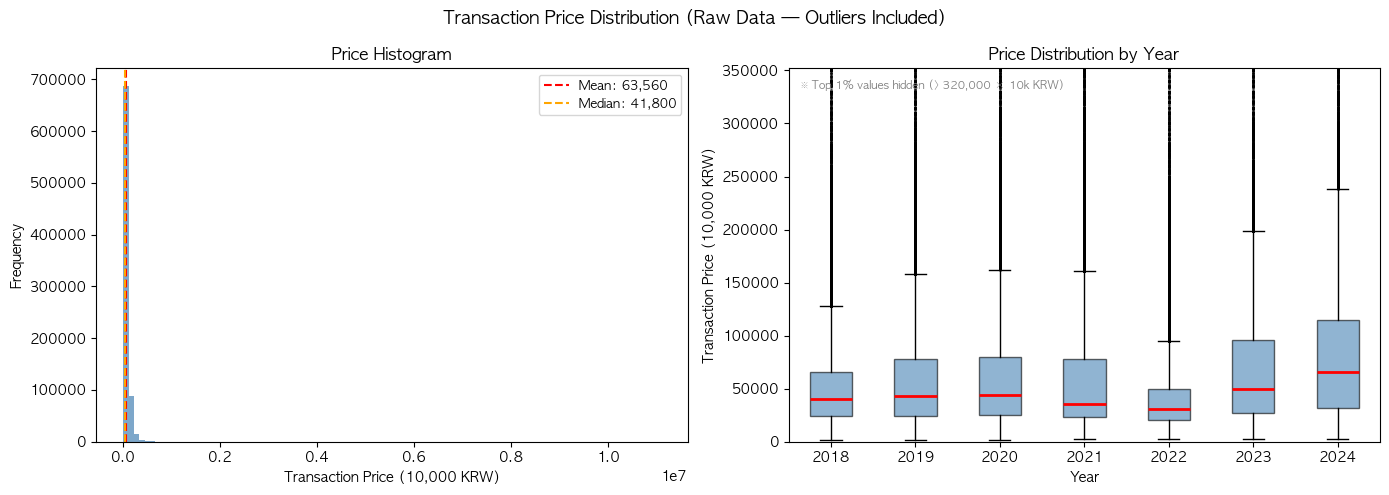


Building type distribution:
building_type
아파트      377363
연립다세대    282391
오피스텔      83339
단독다가구     54252

Average transaction price by building type:
               Avg Price (10k KRW)  Transaction Count
building_type                                        
단독다가구                     125840.6              54252
아파트                        87900.3             377363
연립다세대                      30100.8             282391
오피스텔                       26179.7              83339

Annual market summary:
   year  price_10k_krw  price_per_pyeong  volume  growth_rate_pct
0  2018       54440.89           2371.00  163730              NaN
1  2019       61686.98           2793.49  128341            17.82
2  2020       62344.20           2923.01  174126             4.64
3  2021       62772.64           3176.23  130921             8.66
4  2022       54627.63           3115.02   61399            -1.93
5  2023       75598.97           3726.05   65371            19.62
6  2024       88197.94           4126.

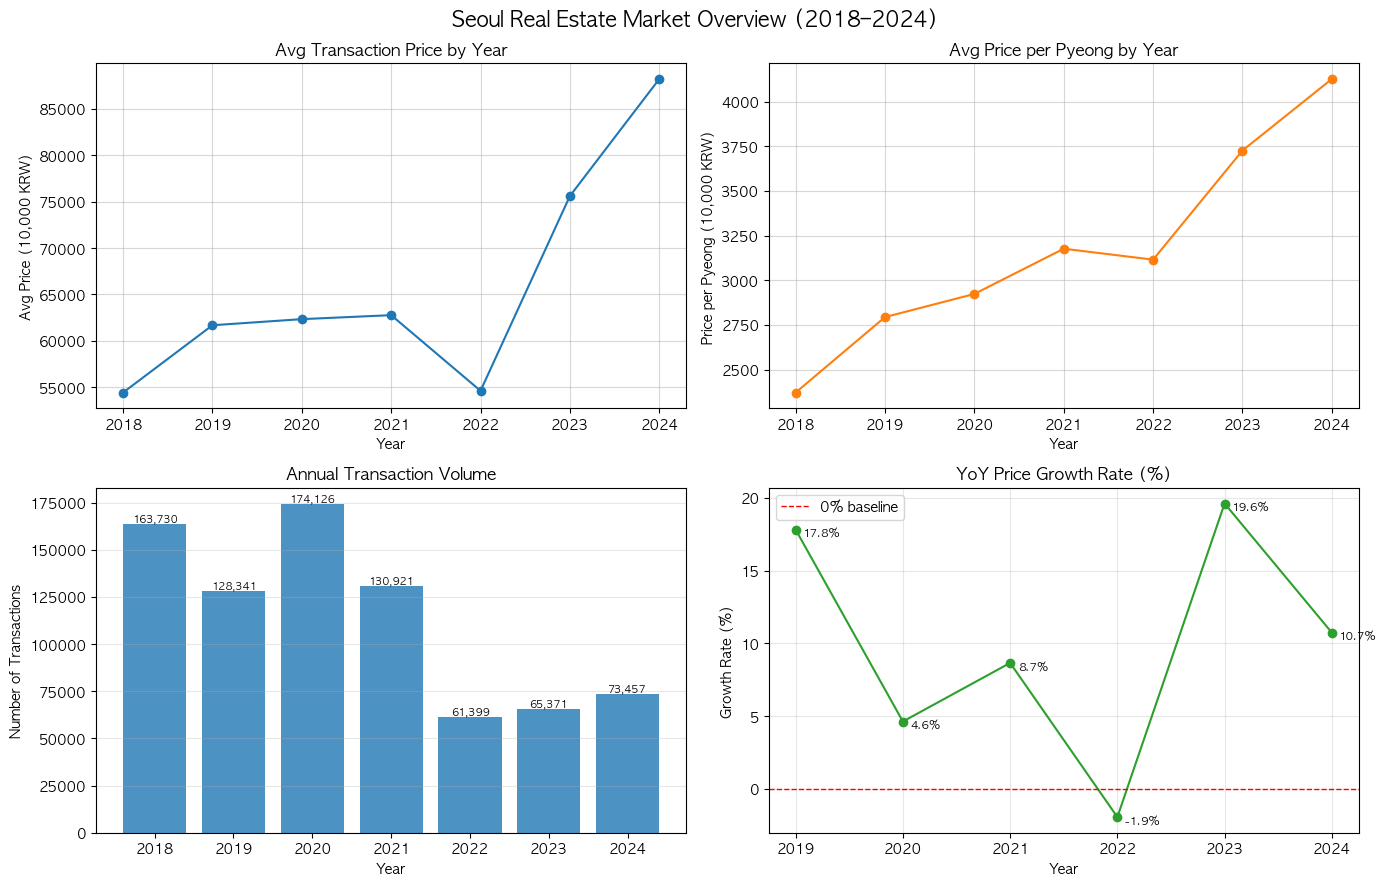

In [69]:
# EDA: Raw Distribution & Market-Wide Trends
# Runs on data BEFORE outlier removal — the 2021-2022 price surge is a real market event, not noise, and belongs in a "what happened to the market" narrative. Outlier treatment (next cell) is reserved for the cross-district scoring section, where one extreme trade could distort a district's Z-score.

print("Dataset Overview (raw, pre-outlier-removal)")
print(f"Total rows : {len(df_all):,} | Total cols : {len(df_all.columns)}")
print("\nDescriptive statistics for key columns:")
print(df_all[["price_10k_krw", "area_sqm", "price_per_pyeong"]].describe().round(1).to_string())
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Transaction Price Distribution (Raw Data — Outliers Included)",
             fontsize=13, fontweight="bold")
 
ax = axes[0]
ax.hist(df_all["price_10k_krw"].dropna(), bins=100, color="steelblue", alpha=0.7, edgecolor="none")
ax.set_title("Price Histogram")
ax.set_xlabel("Transaction Price (10,000 KRW)")
ax.set_ylabel("Frequency")
ax.axvline(df_all["price_10k_krw"].mean(), color="red", linestyle="--", linewidth=1.5,
           label=f"Mean: {df_all['price_10k_krw'].mean():,.0f}")
ax.axvline(df_all["price_10k_krw"].median(), color="orange", linestyle="--", linewidth=1.5,
           label=f"Median: {df_all['price_10k_krw'].median():,.0f}")
ax.legend(fontsize=9)
 
ax = axes[1]
data_by_year = [df_all[df_all["year"] == y]["price_10k_krw"].dropna() for y in years]
bp = ax.boxplot(data_by_year, labels=years, patch_artist=True,
                 medianprops=dict(color="red", linewidth=2),
                 flierprops=dict(marker=".", markersize=2, alpha=0.3))
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.6)
ax.set_title("Price Distribution by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Transaction Price (10,000 KRW)")
p99 = df_all["price_10k_krw"].quantile(0.99)
ax.set_ylim(0, p99 * 1.1)
ax.text(0.02, 0.97, f"※ Top 1% values hidden (> {p99:,.0f} × 10k KRW)",
        transform=ax.transAxes, fontsize=8, color="gray", va="top")
plt.tight_layout()
plt.show()
 
print("\nBuilding type distribution:")
print(df_all["building_type"].value_counts().to_string())
 
bldg_price = (
    df_all.groupby("building_type")["price_10k_krw"].agg(["mean", "count"]).round(1)
    .sort_values("mean", ascending=False)
)
bldg_price.columns = ["Avg Price (10k KRW)", "Transaction Count"]
print("\nAverage transaction price by building type:")
print(bldg_price.to_string())
 
# Annual market summary — price, price/pyeong, transaction volume, YoY growth
year_summary = (
    df_all.groupby("year")["price_10k_krw"].mean().reset_index()
    .merge(df_all.groupby("year")["price_per_pyeong"].mean().reset_index(), on="year")
    .merge(df_all.groupby("year").size().reset_index(name="volume"), on="year")
    .sort_values("year")
)
year_summary["growth_rate_pct"] = year_summary["price_per_pyeong"].pct_change() * 100
print("\nAnnual market summary:")
print(year_summary.round(2))
 
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Seoul Real Estate Market Overview (2018–2024)", fontsize=15, fontweight="bold")
 
ax = axes[0, 0]
ax.plot(year_summary["year"], year_summary["price_10k_krw"], marker="o")
ax.set_title("Avg Transaction Price by Year")
ax.set_xlabel("Year"); ax.set_ylabel("Avg Price (10,000 KRW)")
ax.grid(True, alpha=0.5)
 
ax = axes[0, 1]
ax.plot(year_summary["year"], year_summary["price_per_pyeong"], marker="o", color="tab:orange")
ax.set_title("Avg Price per Pyeong by Year")
ax.set_xlabel("Year"); ax.set_ylabel("Price per Pyeong (10,000 KRW)")
ax.grid(True, alpha=0.5)
 
ax = axes[1, 0]
ax.bar(year_summary["year"], year_summary["volume"], alpha=0.8)
ax.set_title("Annual Transaction Volume")
ax.set_xlabel("Year"); ax.set_ylabel("Number of Transactions")
for i, v in enumerate(year_summary["volume"]):
    ax.text(year_summary["year"].iloc[i], v, f"{v:,}", ha="center", va="bottom", fontsize=7.5)
ax.grid(axis="y", alpha=0.3)
 
ax = axes[1, 1]
ax.plot(year_summary["year"], year_summary["growth_rate_pct"], marker="o", color="tab:green")
ax.axhline(0, color="red", linestyle="--", linewidth=1, label="0% baseline")
ax.set_title("YoY Price Growth Rate (%)")
ax.set_xlabel("Year"); ax.set_ylabel("Growth Rate (%)")
ax.grid(True, alpha=0.3); ax.legend()
for i, v in enumerate(year_summary["growth_rate_pct"]):
    if pd.notna(v):
        ax.text(year_summary["year"].iloc[i] + 0.07, v - 0.5, f"{v:.1f}%", fontsize=8)
plt.tight_layout()
plt.show()

IQR outlier removal: 51,257 rows removed (6.4%)
Bounds: [-57,550, 161,250] × 10k KRW


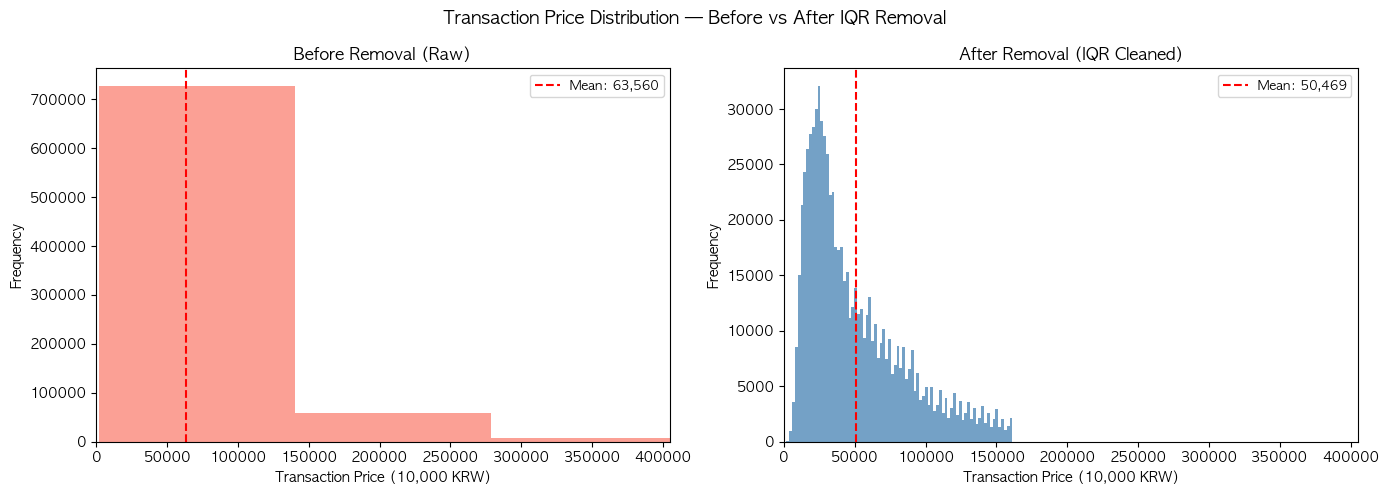

In [70]:
# %% CELL 6 — Outlier Treatment (IQR)
# From this point on, df_all is used for all district/dong/building-type comparisons — a single extreme-price transaction in one district could otherwise dominate that district's Z-score and distort the ranking.
df_before_outlier = df_all.copy()
 
Q1 = df_all["price_10k_krw"].quantile(0.25)
Q3 = df_all["price_10k_krw"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
 
df_all = df_all[(df_all["price_10k_krw"] >= lower) & (df_all["price_10k_krw"] <= upper)]
 
removed_n = len(df_before_outlier) - len(df_all)
print(f"IQR outlier removal: {removed_n:,} rows removed "
      f"({removed_n / len(df_before_outlier) * 100:.1f}%)")
print(f"Bounds: [{lower:,.0f}, {upper:,.0f}] × 10k KRW")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Transaction Price Distribution — Before vs After IQR Removal",
             fontsize=13, fontweight="bold")
for ax, df_plot, title, color in [
    (axes[0], df_before_outlier, "Before Removal (Raw)", "salmon"),
    (axes[1], df_all, "After Removal (IQR Cleaned)", "steelblue"),
]:
    ax.hist(df_plot["price_10k_krw"].dropna(), bins=80, color=color, alpha=0.75, edgecolor="none")
    ax.set_title(title)
    ax.set_xlabel("Transaction Price (10,000 KRW)"); ax.set_ylabel("Frequency")
    mean_val = df_plot["price_10k_krw"].mean()
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:,.0f}")
    ax.legend(fontsize=9)
    ax.set_xlim(0, df_before_outlier["price_10k_krw"].quantile(0.995))
plt.tight_layout()
plt.show()

In [71]:
# District-Level Metric Engineering
# Three core metrics per district, each capturing a different dimension of investment attractiveness:
#   growth — average YoY price/pyeong growth, 2018-2024
#   growth_volatility — std dev of that growth (risk / stability)
#   relative_price_ratio — current price/pyeong vs. the Seoul average (>1 = pricier than average, <1 = undervalued)
avg_price_district = (
    df_all.groupby("district")["price_10k_krw"].mean().reset_index().round(2)
    .sort_values("price_10k_krw", ascending=False).reset_index(drop=True)
)
avg_py_district = (
    df_all.groupby("district")["price_per_pyeong"].mean().reset_index().round(2)
    .sort_values("price_per_pyeong", ascending=False).reset_index(drop=True)
)
 
price_pivot = df_all.pivot_table(
    index="district", columns="year", values="price_per_pyeong", aggfunc="mean"
).reset_index()
 
district_metrics = price_pivot.copy()
for i in range(1, len(years)):
    pre_y, cur_y = years[i - 1], years[i]
    district_metrics[f"growth_{pre_y}_{cur_y}"] = (
        (district_metrics[cur_y] - district_metrics[pre_y]) / district_metrics[pre_y] * 100
    )
 
growth_cols = [c for c in district_metrics.columns if str(c).startswith("growth_")]
district_metrics["avg_growth_rate"] = district_metrics[growth_cols].mean(axis=1).round(4)
district_metrics["growth_volatility"] = district_metrics[growth_cols].std(axis=1).round(4)
 
latest_year = years[-1]
district_metrics["current_price_per_pyeong"] = district_metrics[latest_year]
seoul_avg_price = district_metrics["current_price_per_pyeong"].mean()
district_metrics["relative_price_ratio"] = district_metrics["current_price_per_pyeong"] / seoul_avg_price
 
print("District-level metrics (growth / volatility / relative price):")
print(district_metrics[["district", "avg_growth_rate", "growth_volatility",
                         "relative_price_ratio"]].round(3).to_string(index=False))

District-level metrics (growth / volatility / relative price):
district  avg_growth_rate  growth_volatility  relative_price_ratio
     강남구            4.355              8.845                 1.403
     강동구            9.144              9.983                 1.143
     강북구            6.517              5.606                 0.613
     강서구            6.914              6.572                 0.805
     관악구            6.662              4.459                 0.760
     광진구            8.613              4.874                 1.077
     구로구            7.320              6.189                 0.744
     금천구            9.934              6.221                 0.768
     노원구            8.664             11.838                 0.836
     도봉구            6.240              5.374                 0.591
    동대문구            9.260             10.322                 0.983
     동작구            9.255              9.123                 1.146
     마포구            7.916              7.014                 1.194

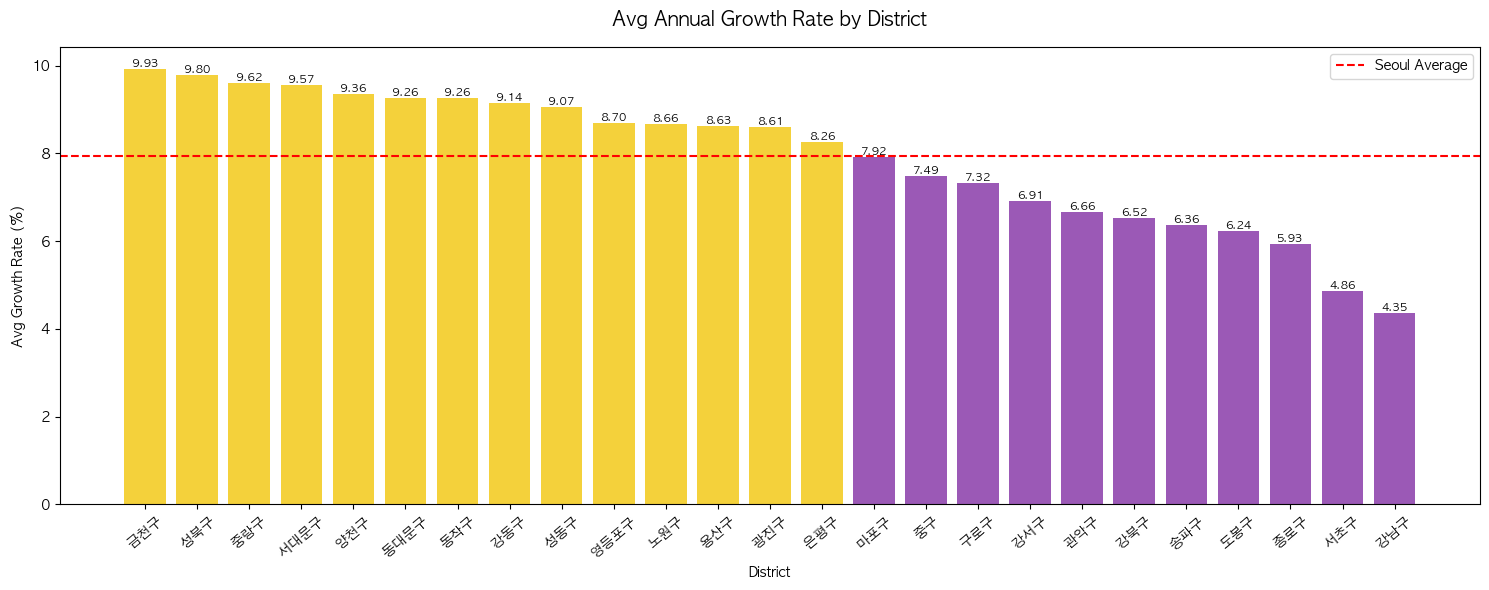

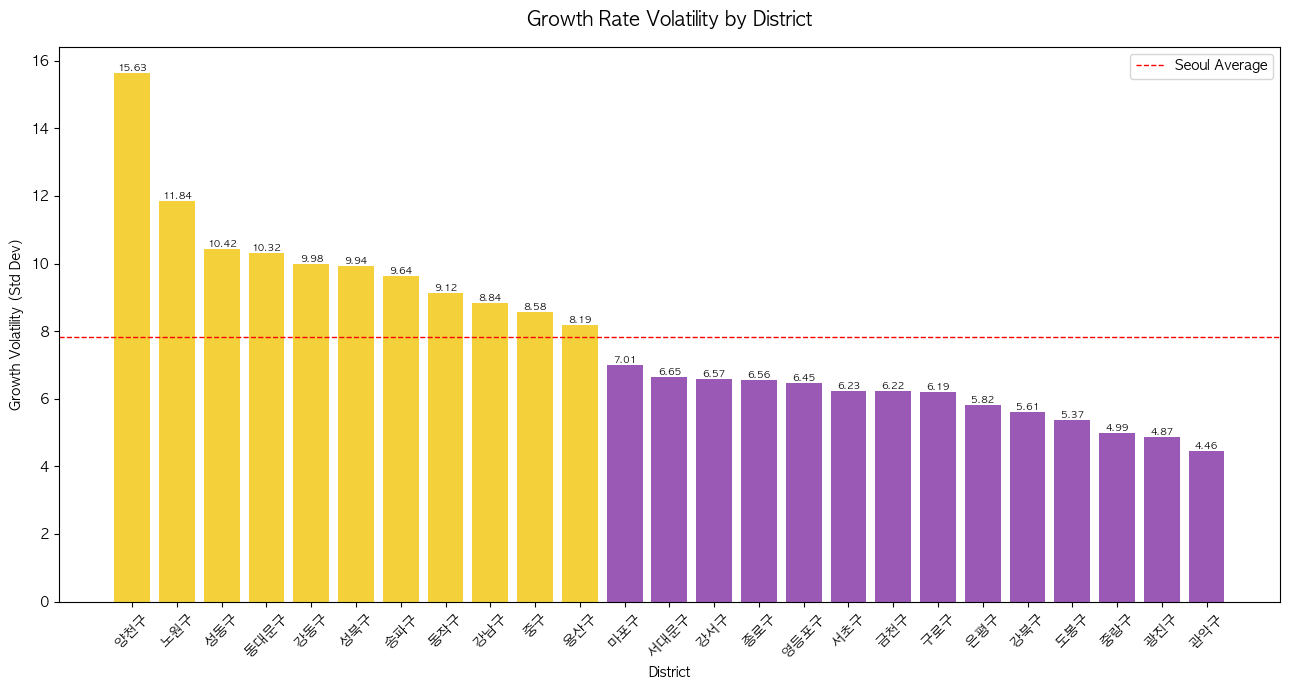

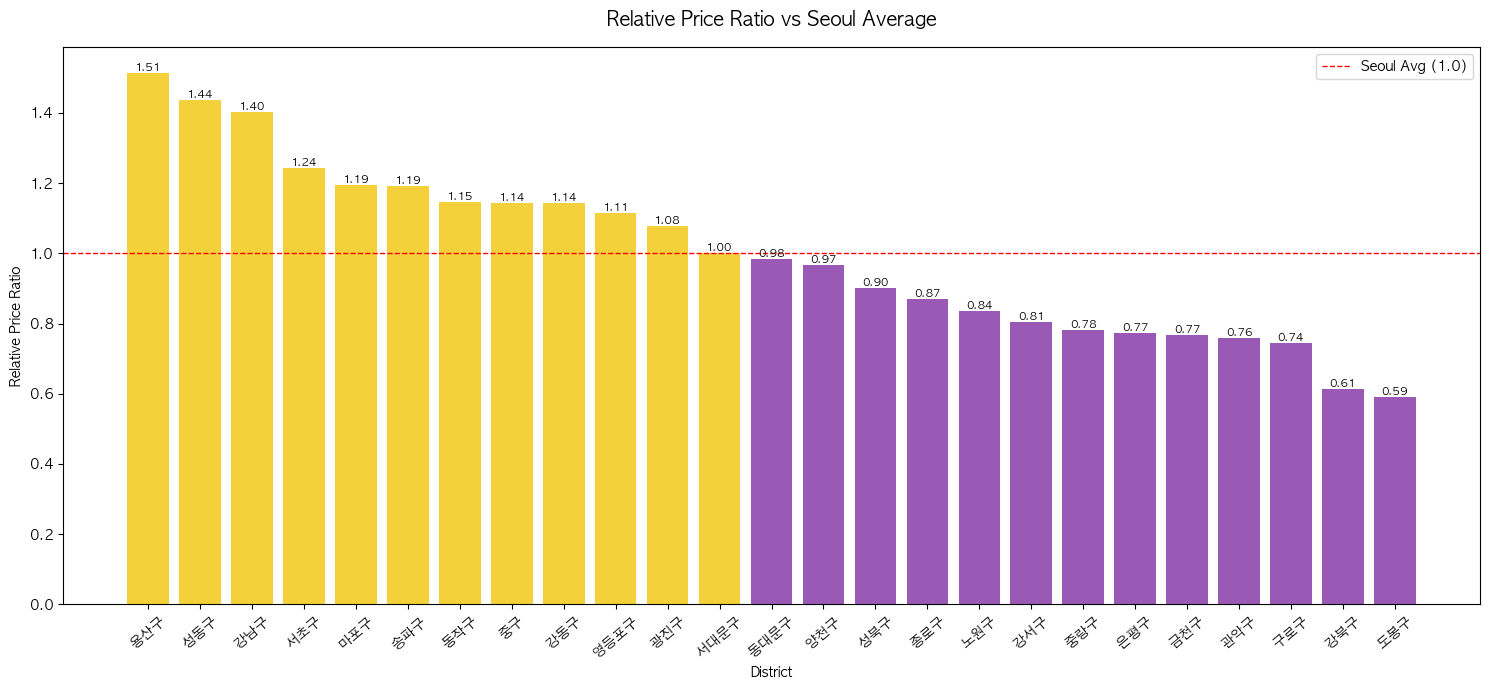

In [72]:
# District-Level Descriptive Visualizations
# Growth, volatility, and relative price shown separately before they're combined into a single score (CELL 10) — useful to see which districts drive the eventual ranking through which metric.

df_growth = district_metrics[["district", "avg_growth_rate"]].sort_values(
    "avg_growth_rate", ascending=False).reset_index(drop=True)
seoul_avg_growth = df_growth["avg_growth_rate"].mean()
colors = ["#F4D13B" if g >= seoul_avg_growth else "#9b59b6" for g in df_growth["avg_growth_rate"]]
 
plt.figure(figsize=(15, 6))
plt.bar(range(len(df_growth)), df_growth["avg_growth_rate"], color=colors)
plt.xticks(range(len(df_growth)), df_growth["district"], rotation=40)
plt.title("Avg Annual Growth Rate by District", pad=15, fontsize=14, fontweight="bold")
plt.xlabel("District"); plt.ylabel("Avg Growth Rate (%)")
plt.axhline(y=seoul_avg_growth, color="red", linestyle="--", linewidth=1.5, label="Seoul Average")
plt.legend(loc="upper right")
for i, v in enumerate(df_growth["avg_growth_rate"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()
 
df_vol = district_metrics[["district", "growth_volatility"]].sort_values(
    "growth_volatility", ascending=False).reset_index(drop=True)
seoul_avg_vol = df_vol["growth_volatility"].mean()
colors = ["#9b59b6" if v <= seoul_avg_vol else "#F4D13B" for v in df_vol["growth_volatility"]]
 
plt.figure(figsize=(13, 7))
plt.bar(range(len(df_vol)), df_vol["growth_volatility"], color=colors)
plt.xticks(range(len(df_vol)), df_vol["district"], rotation=45)
plt.title("Growth Rate Volatility by District", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("District"); plt.ylabel("Growth Volatility (Std Dev)")
plt.axhline(seoul_avg_vol, color="red", linestyle="--", linewidth=1, label="Seoul Average")
plt.legend(loc="upper right")
for i, v in enumerate(df_vol["growth_volatility"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.show()
 
df_price_ratio = district_metrics[["district", "relative_price_ratio"]].sort_values(
    "relative_price_ratio", ascending=False).reset_index(drop=True)
colors = ["#F4D13B" if r > 1 else "#9b59b6" for r in df_price_ratio["relative_price_ratio"]]
 
plt.figure(figsize=(15, 7))
plt.bar(range(len(df_price_ratio)), df_price_ratio["relative_price_ratio"], color=colors)
plt.xticks(range(len(df_price_ratio)), df_price_ratio["district"], rotation=40)
plt.title("Relative Price Ratio vs Seoul Average", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("District"); plt.ylabel("Relative Price Ratio")
plt.axhline(1, color="red", linestyle="--", linewidth=1, label="Seoul Avg (1.0)")
plt.legend(loc="upper right")
for i, v in enumerate(df_price_ratio["relative_price_ratio"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

In [73]:
# Statistical Significance Testing (ANOVA)
# The district metrics above show descriptive differences — but with ~750K transactions, almost ANY difference will register as statistically significant. Eta-squared (effect size) answers the more useful question: how much of the actual price variance is explained by district, not just whether the difference is detectable.

print("ANOVA — price_per_pyeong across all districts")
 
district_groups = [
    grp["price_per_pyeong"].dropna().values
    for _, grp in df_all.groupby("district")
]
f_stat, p_value = stats.f_oneway(*district_groups)
print(f"F-statistic: {f_stat:,.2f} | p-value: {p_value:.2e}")
if p_value < 0.05:
    print("-> Reject H0: at least one district's mean price_per_pyeong "
          "differs significantly from the others (α=0.05).")
else:
    print("-> Fail to reject H0: no significant difference detected across districts.")
 
grand_mean = df_all["price_per_pyeong"].mean()
ss_between = sum(
    len(grp) * (grp["price_per_pyeong"].mean() - grand_mean) ** 2
    for _, grp in df_all.groupby("district")
)
ss_total = ((df_all["price_per_pyeong"] - grand_mean) ** 2).sum()
eta_squared = ss_between / ss_total
print(f"Eta-squared (effect size): {eta_squared:.4f} "
      f"({eta_squared * 100:.1f}% of price variance explained by district)")
 
 
def top3_vs_rest_ttest(df_all, rank_df, label):
    """Welch's t-test comparing a profile's TOP3 districts against the
    remaining 22. Welch's (not Student's) t-test is used because district
    sample sizes vary widely, violating the equal-variance assumption.
    Called later in CELL 11, once conservative/balanced/aggressive_rank exist.
    """
    top3 = rank_df.head(3)["district"].tolist()
    top3_prices = df_all[df_all["district"].isin(top3)]["price_per_pyeong"].dropna()
    rest_prices = df_all[~df_all["district"].isin(top3)]["price_per_pyeong"].dropna()
 
    t_stat, p_val = stats.ttest_ind(top3_prices, rest_prices, equal_var=False)
    print(f"\n[{label}] TOP3 districts: {top3}")
    print(f"  TOP3 mean price/pyeong: {top3_prices.mean():,.0f} (n = {len(top3_prices):,})")
    print(f"  Rest mean price/pyeong: {rest_prices.mean():,.0f} (n = {len(rest_prices):,})")
    print(f"  Welch t-statistic: {t_stat:.3f} | p-value: {p_val:.2e}")
    if p_val < 0.05:
        print("  -> Significant difference between TOP3 and the rest (α=0.05).")
    else:
        print("  -> No significant difference detected — interpret with caution.")
    return t_stat, p_val

ANOVA — price_per_pyeong across all districts
F-statistic: 7,123.67 | p-value: 0.00e+00
-> Reject H0: at least one district's mean price_per_pyeong differs significantly from the others (α=0.05).
Eta-squared (effect size): 0.1864 (18.6% of price variance explained by district)


Correlation matrix (3 core metrics):
year              growth_score  price_score  volatility_score
year                                                         
growth_score             1.000        0.033            -0.299
price_score              0.033        1.000             0.350
volatility_score        -0.299        0.350             1.000


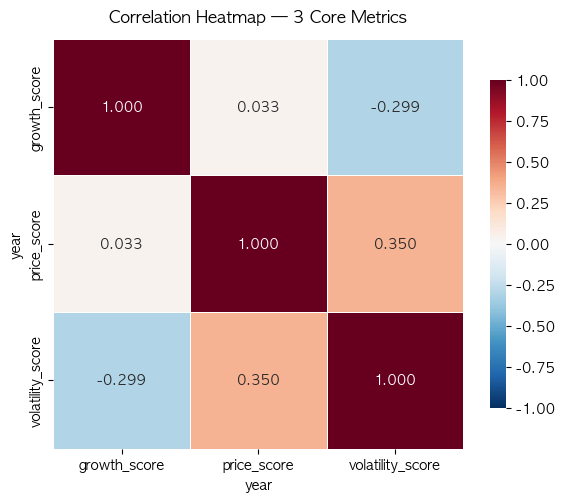

Max absolute correlation: 0.350 (metrics are sufficiently independent)

=== Conservative TOP3 ===
district  conservative_score  growth_score  price_score  volatility_score
     중랑구             3.01860        1.0590       0.8637            1.0836
     도봉구             2.49525       -1.0716       1.6260            0.9367
     관악구             2.48325       -0.8053       0.9551            1.2872

=== Balanced TOP3 ===
district  balanced_score  growth_score  price_score  volatility_score
     중랑구          3.0063        1.0590       0.8637            1.0836
     금천구          2.7965        1.2591       0.9249            0.6125
     은평구          1.8723        0.2036       0.9029            0.7658

=== Aggressive TOP3 ===
district  aggressive_score  growth_score  price_score  volatility_score
     금천구           3.11980        1.2591       0.9249            0.6125
     중랑구           2.99400        1.0590       0.8637            1.0836
    서대문구           1.75875        1.0280      -0.0083         

In [74]:
# Z-Score Normalization & Investor-Profile Scoring
# Growth (%), price (10k KRW/pyeong), and volatility (%) live on
# different scales — summing them directly would let the largest-scale
# variable (price) dominate. Z-score standardizes all three to mean=0,
# std=1 before combining. Price and volatility are sign-flipped so that,
# after flipping, "higher score" always means "more attractive" for all three metrics.
district_scores = district_metrics.copy()
 
mean_growth = district_scores["avg_growth_rate"].mean()
std_growth = district_scores["avg_growth_rate"].std()
mean_price = district_scores["current_price_per_pyeong"].mean()
std_price = district_scores["current_price_per_pyeong"].std()
mean_vol = district_scores["growth_volatility"].mean()
std_vol = district_scores["growth_volatility"].std()
 
district_scores["growth_z"] = (district_scores["avg_growth_rate"] - mean_growth) / std_growth
district_scores["price_z"] = (district_scores["current_price_per_pyeong"] - mean_price) / std_price
district_scores["volatility_z"] = (district_scores["growth_volatility"] - mean_vol) / std_vol
 
district_scores["growth_score"] = district_scores["growth_z"].round(4)          # higher growth = better, no flip
district_scores["price_score"] = -district_scores["price_z"].round(4)           # lower price = better, flip sign
district_scores["volatility_score"] = -district_scores["volatility_z"].round(4)  # lower volatility = better, flip sign
 
# Independence check: if two metrics correlate strongly (|r| > 0.8), they
# carry near-identical information and summing them would double-count it.
corr_df = district_scores[["growth_score", "price_score", "volatility_score"]].corr().round(3)
print("Correlation matrix (3 core metrics):")
print(corr_df.to_string())
 
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df, annot=True, fmt=".3f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap — 3 Core Metrics", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()
 
max_corr = corr_df.abs().where(~np.eye(len(corr_df), dtype=bool)).max().max()
print(f"Max absolute correlation: {max_corr:.3f} "
      f"({'metrics are sufficiently independent' if max_corr < 0.5 else 'interpret with some caution'})")
 
# Weighted composite score per investor profile. All three weight sets
# sum to 3.0, so scores stay on a comparable scale across profiles.
#   Conservative — prioritizes stability (volatility weight highest)
#   Balanced     — equal weight on all three metrics
#   Aggressive   — prioritizes growth (growth weight highest)
district_scores["conservative_score"] = (
    0.5 * district_scores["growth_score"] + 1.0 * district_scores["price_score"] + 1.5 * district_scores["volatility_score"]
)
district_scores["balanced_score"] = (
    1.0 * district_scores["growth_score"] + 1.0 * district_scores["price_score"] + 1.0 * district_scores["volatility_score"]
)
district_scores["aggressive_score"] = (
    1.5 * district_scores["growth_score"] + 1.0 * district_scores["price_score"] + 0.5 * district_scores["volatility_score"]
)
 
conservative_rank = district_scores.sort_values("conservative_score", ascending=False).reset_index(drop=True)
balanced_rank = district_scores.sort_values("balanced_score", ascending=False).reset_index(drop=True)
aggressive_rank = district_scores.sort_values("aggressive_score", ascending=False).reset_index(drop=True)
 
print("\n=== Conservative TOP3 ===")
print(conservative_rank[["district", "conservative_score", "growth_score", "price_score", "volatility_score"]].head(3).to_string(index=False))
print("\n=== Balanced TOP3 ===")
print(balanced_rank[["district", "balanced_score", "growth_score", "price_score", "volatility_score"]].head(3).to_string(index=False))
print("\n=== Aggressive TOP3 ===")
print(aggressive_rank[["district", "aggressive_score", "growth_score", "price_score", "volatility_score"]].head(3).to_string(index=False))

In [75]:
# Welch's t-test: TOP3 vs. the Rest (per profile)
print("Welch's t-test — TOP3 districts vs. the rest, by profile")
top3_vs_rest_ttest(df_all, conservative_rank, "Conservative")
top3_vs_rest_ttest(df_all, balanced_rank, "Balanced")
top3_vs_rest_ttest(df_all, aggressive_rank, "Aggressive")

Welch's t-test — TOP3 districts vs. the rest, by profile

[Conservative] TOP3 districts: ['중랑구', '도봉구', '관악구']
  TOP3 mean price/pyeong: 2,109 (n = 89,783)
  Rest mean price/pyeong: 2,863 (n = 656,305)
  Welch t-statistic: -207.762 | p-value: 0.00e+00
  -> Significant difference between TOP3 and the rest (α=0.05).

[Balanced] TOP3 districts: ['중랑구', '금천구', '은평구']
  TOP3 mean price/pyeong: 2,190 (n = 99,703)
  Rest mean price/pyeong: 2,862 (n = 646,385)
  Welch t-statistic: -187.056 | p-value: 0.00e+00
  -> Significant difference between TOP3 and the rest (α=0.05).

[Aggressive] TOP3 districts: ['금천구', '중랑구', '서대문구']
  TOP3 mean price/pyeong: 2,384 (n = 77,220)
  Rest mean price/pyeong: 2,817 (n = 668,868)
  Welch t-statistic: -97.084 | p-value: 0.00e+00
  -> Significant difference between TOP3 and the rest (α=0.05).


(np.float64(-97.08364930121692), np.float64(0.0))

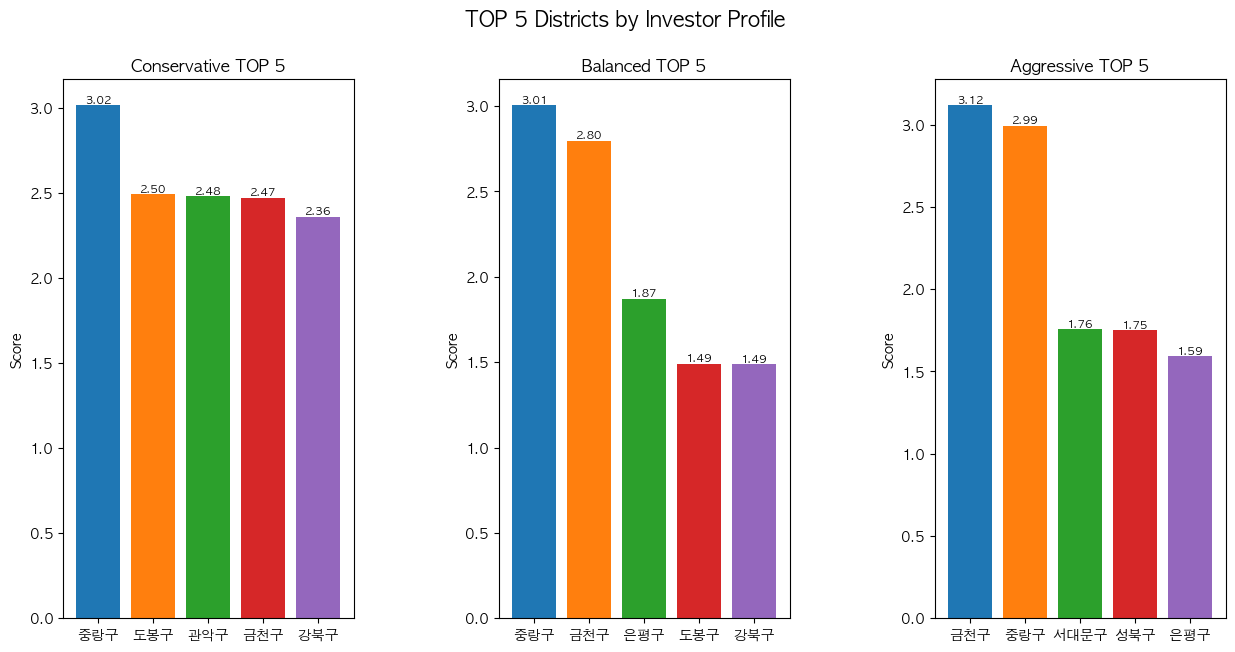

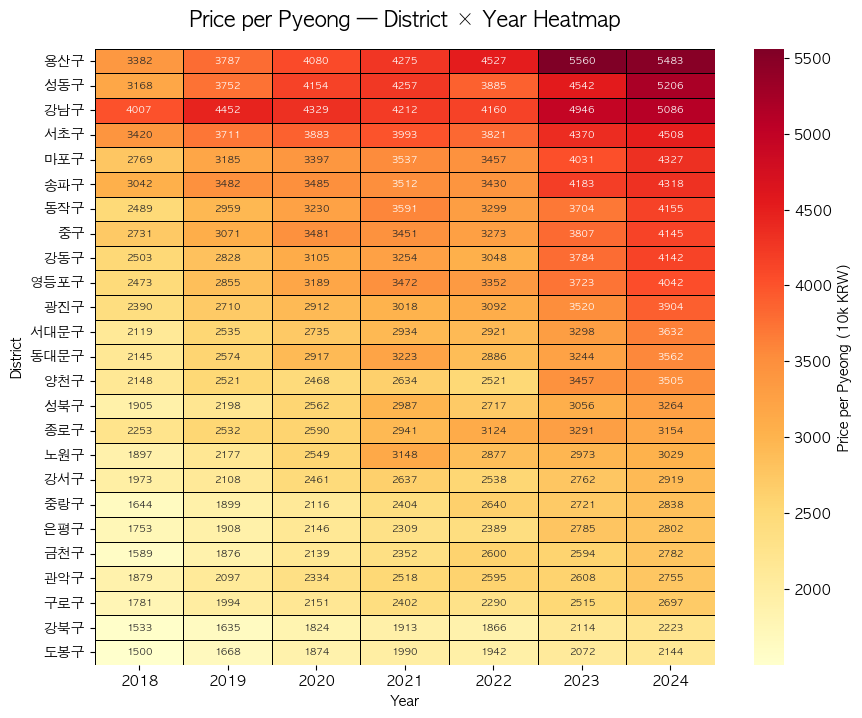

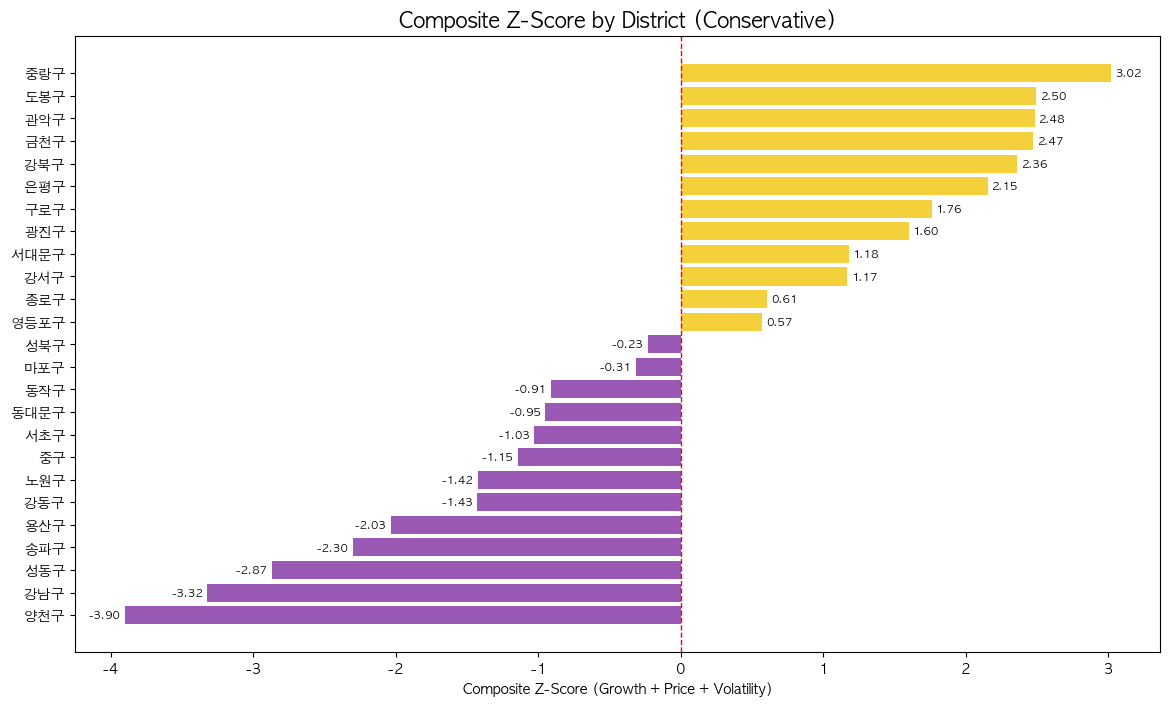

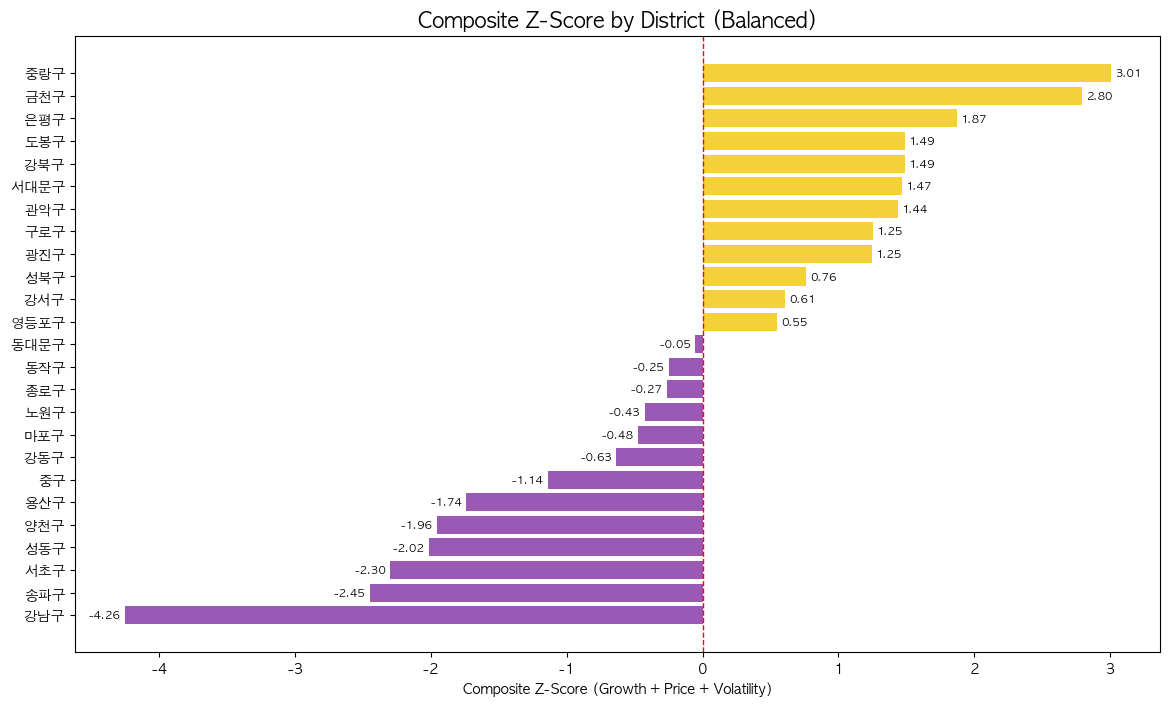

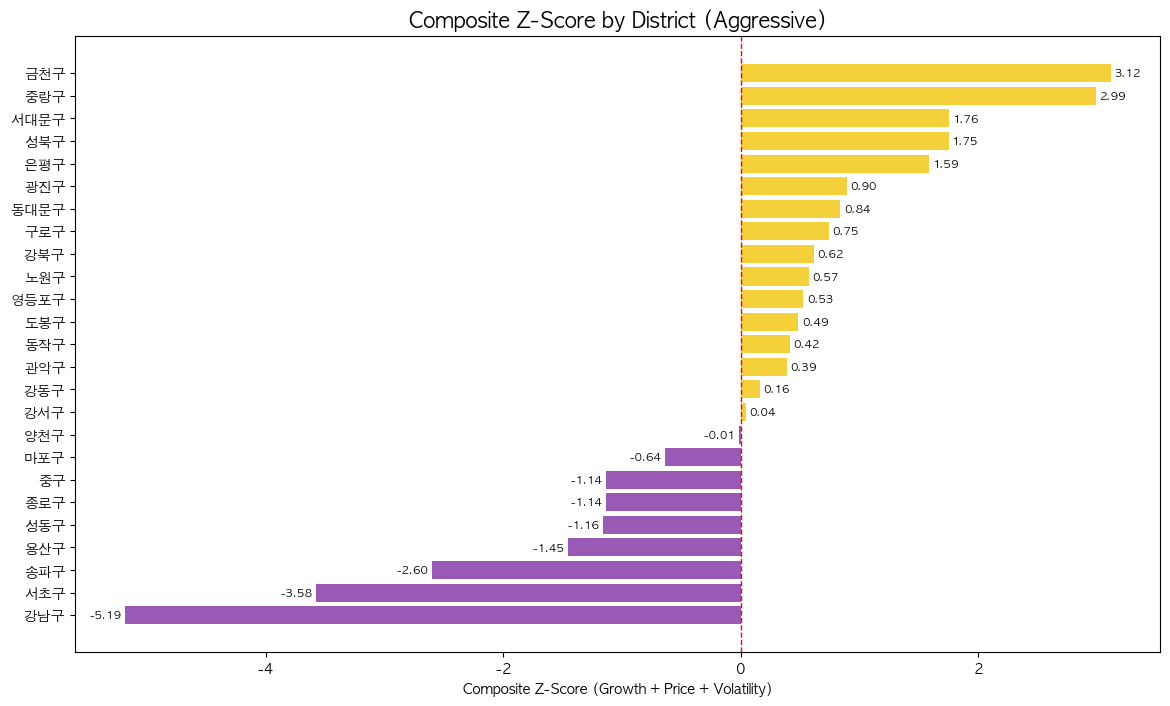

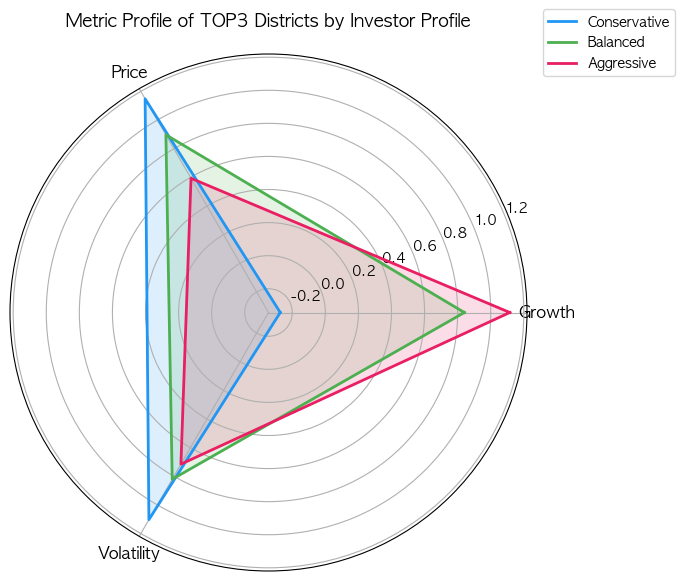

In [76]:
# Profile-Level Visualizations
# TOP5 bar charts, a district x year price heatmap, per-profile Z-score
# composite bars, and a radar chart comparing each profile's metric
# emphasis. These are the headline visuals for the recommendation story.
cons_top5 = conservative_rank.head(5)[["district", "conservative_score"]]
bal_top5 = balanced_rank.head(5)[["district", "balanced_score"]]
aggr_top5 = aggressive_rank.head(5)[["district", "aggressive_score"]]
bar_colors5 = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
 
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.suptitle("TOP 5 Districts by Investor Profile", fontsize=15)
fig.subplots_adjust(wspace=0.5)
for ax, df_top, score_col, title in [
    (axes[0], cons_top5, "conservative_score", "Conservative TOP 5"),
    (axes[1], bal_top5, "balanced_score", "Balanced TOP 5"),
    (axes[2], aggr_top5, "aggressive_score", "Aggressive TOP 5"),
]:
    ax.bar(range(len(df_top)), df_top[score_col], color=bar_colors5[:len(df_top)])
    ax.set_xticks(range(len(df_top)))
    ax.set_xticklabels(df_top["district"])
    ax.set_title(title)
    ax.set_ylabel("Score")
    for i, v in enumerate(df_top[score_col]):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
plt.show()
 
latest_year_h = max(years)
df_heat = price_pivot.copy().sort_values(latest_year_h, ascending=False).set_index("district")[years]
 
plt.figure(figsize=(10, 8))
sns.heatmap(df_heat, cmap="YlOrRd", linewidths=0.5, linecolor="black",
            cbar_kws={"label": "Price per Pyeong (10k KRW)"},
            annot=True, annot_kws={"fontsize": 7}, fmt=".0f")
plt.title("Price per Pyeong — District × Year Heatmap", pad=16, fontsize=15, fontweight="bold")
plt.xlabel("Year"); plt.ylabel("District")
plt.show()
 
for score_col, title in [
    ("conservative_score", "Conservative"),
    ("balanced_score", "Balanced"),
    ("aggressive_score", "Aggressive"),
]:
    df_plot = district_scores[["district", score_col]].sort_values(score_col, ascending=True).reset_index(drop=True)
    colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in df_plot[score_col]]
    plt.figure(figsize=(14, 8))
    plt.barh(range(len(df_plot)), df_plot[score_col], color=colors)
    plt.yticks(range(len(df_plot)), df_plot["district"])
    plt.title(f"Composite Z-Score by District ({title})", fontsize=15, fontweight="bold")
    plt.xlabel("Composite Z-Score (Growth + Price + Volatility)")
    plt.axvline(0, color="red", linestyle="--", linewidth=1)
    for i, v in enumerate(df_plot[score_col]):
        x_pos = v + 0.03 if v >= 0 else v - 0.03
        ha = "left" if v >= 0 else "right"
        plt.text(x_pos, i, f"{v:.2f}", va="center", ha=ha, fontsize=8)
    plt.show()
 
 
def get_avg_scores(rank_df, n=3):
    top = rank_df.head(n)
    return {
        "Growth": top["growth_score"].mean(),
        "Price": top["price_score"].mean(),
        "Volatility": top["volatility_score"].mean(),
    }
 
 
metrics_cons = get_avg_scores(conservative_rank)
metrics_bal = get_avg_scores(balanced_rank)
metrics_aggr = get_avg_scores(aggressive_rank)
 
categories = ["Growth", "Price", "Volatility"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
 
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for metrics, label, color in [
    (metrics_cons, "Conservative", "#2196F3"),
    (metrics_bal, "Balanced", "#4CAF50"),
    (metrics_aggr, "Aggressive", "#E91E63"),
]:
    values = [metrics[c] for c in categories]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=label, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)
 
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_title("Metric Profile of TOP3 Districts by Investor Profile", pad=20, fontsize=13, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

[Model sample] 703,065 rows retained (43,023 dropped for missing predictor values, 5.8%)
Model formula: log_price_per_pyeong ~ C(district) + C(building_type) + building_age + C(year) + floor
                             OLS Regression Results                             
Dep. Variable:     log_price_per_pyeong   R-squared:                       0.543
Model:                              OLS   Adj. R-squared:                  0.543
Method:                   Least Squares   F-statistic:                 2.458e+04
Date:                  Thu, 30 Jul 2026   Prob (F-statistic):               0.00
Time:                          14:10:14   Log-Likelihood:            -2.3685e+05
No. Observations:                703065   AIC:                         4.738e+05
Df Residuals:                    703030   BIC:                         4.742e+05
Df Model:                            34                                         
Covariance Type:              nonrobust                                         

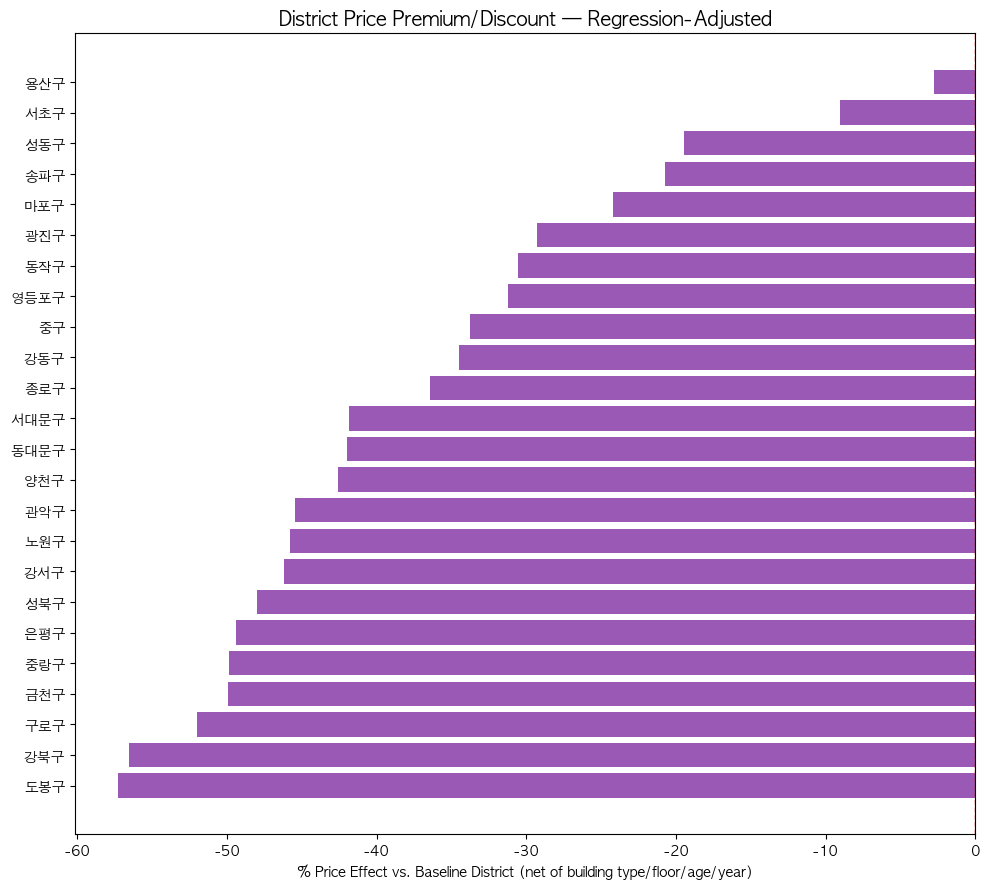

In [77]:
# Regression: Price Determinant Decomposition
# The Z-score framework compares raw district-level averages. 
# This regression asks a sharper question: controlling for building type,floor, age, and year, does the district itself still carry a price premium or discount? 
# A district that looked expensive above but loses its premium here was mostly expensive because of WHAT's built there (e.g. newer stock), not the location itself.
#
# Log-transformed target because price distributions are right-skewed even after IQR cleaning; log-linear coefficients read as approximate % effects. 
# Year is treated as categorical (fixed effect) rather than a linear trend, since 2018-2024 clearly wasn't a straight line.

model_df = df_all.copy()
 
before_n = len(model_df)
model_df = model_df[model_df["price_per_pyeong"] > 0]
dropped_n = before_n - len(model_df)
if dropped_n:
    print(f"[Data check] Dropped {dropped_n} rows with non-positive price_per_pyeong.")
 
model_df["log_price_per_pyeong"] = np.log(model_df["price_per_pyeong"])
 
model_cols = ["log_price_per_pyeong", "district", "building_type", "building_age", "year"]
optional_cols = [c for c in ["floor"] if c in model_df.columns]
model_cols += optional_cols
 
before_n = len(model_df)
model_df = model_df[model_cols].dropna()
print(f"[Model sample] {len(model_df):,} rows retained "
      f"({before_n - len(model_df):,} dropped for missing predictor values, "
      f"{(before_n - len(model_df)) / before_n * 100:.1f}%)")
 
formula_parts = ["C(district)", "C(building_type)", "building_age", "C(year)"]
if "floor" in optional_cols:
    formula_parts.append("floor")
 
formula = "log_price_per_pyeong ~ " + " + ".join(formula_parts)
print(f"Model formula: {formula}")
 
ols_model = smf.ols(formula=formula, data=model_df).fit()
print(ols_model.summary())
 
coef_df = ols_model.params.reset_index()
coef_df.columns = ["term", "coefficient"]
district_effects = coef_df[coef_df["term"].str.startswith("C(district)")].copy()
district_effects["district"] = district_effects["term"].str.extract(r"\[T\.(.+)\]")
district_effects["pct_effect_vs_baseline"] = (np.exp(district_effects["coefficient"]) - 1) * 100
district_effects = district_effects.sort_values("pct_effect_vs_baseline", ascending=False)
 
print("\nDistrict effect on price/pyeong, net of building type/floor/age/year "
      "(% vs. baseline district):")
print(district_effects[["district", "pct_effect_vs_baseline"]].round(2).to_string(index=False))
 
age_coef = ols_model.params.get("building_age", np.nan)
age_pval = ols_model.pvalues.get("building_age", np.nan)
if not np.isnan(age_coef):
    pct_per_year = (np.exp(age_coef) - 1) * 100
    print(f"\nBuilding age effect: {pct_per_year:+.3f}% price change per additional year of age (p={age_pval:.2e})")
 
print(f"\nR-squared: {ols_model.rsquared:.3f} | Adj. R-squared: {ols_model.rsquared_adj:.3f}")
 
# Note on interpreting district effects against the Z-score ranking above:
# a district can rank well on relative_price_ratio (raw average price is
# low) while still showing a low regression-adjusted district effect
# (its housing stock composition — e.g. more low-rise/older units —
# explains most of that low average, not the location itself). Both
# numbers are valid; they answer different questions ("is the current
# average price low?" vs. "is the location itself, holding stock
# composition fixed, cheap?"). Worth stating explicitly rather than
# treating a mismatch between the two as an error.
 
plt.figure(figsize=(10, 9))
plot_df = district_effects.sort_values("pct_effect_vs_baseline")
colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in plot_df["pct_effect_vs_baseline"]]
plt.barh(plot_df["district"], plot_df["pct_effect_vs_baseline"], color=colors)
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("% Price Effect vs. Baseline District (net of building type/floor/age/year)")
plt.title("District Price Premium/Discount — Regression-Adjusted", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Weight Scenario -> TOP3 District Comparison
Conservative Base (0.5/1.0/1.5)
  TOP3: 중랑구, 도봉구, 관악구
Conservative Alt1 (0.3/1.0/1.7)
  TOP3: 중랑구, 관악구, 도봉구
Conservative Alt2 (0.7/1.0/1.3)
  TOP3: 중랑구, 금천구, 도봉구
Balanced Base (1.0/1.0/1.0)
  TOP3: 중랑구, 금천구, 은평구
Aggressive Base (1.5/1.0/0.5)
  TOP3: 금천구, 중랑구, 서대문구
Aggressive Alt1 (1.7/1.0/0.3)
  TOP3: 금천구, 중랑구, 성북구
Aggressive Alt2 (1.3/1.0/0.7)
  TOP3: 중랑구, 금천구, 은평구

District frequency in TOP3 across all scenarios:
  중랑구     : ███████ (7/7 scenarios)
  금천구     : █████ (5/7 scenarios)
  도봉구     : ███ (3/7 scenarios)
  관악구     : ██ (2/7 scenarios)
  은평구     : ██ (2/7 scenarios)
  서대문구    : █ (1/7 scenarios)
  성북구     : █ (1/7 scenarios)


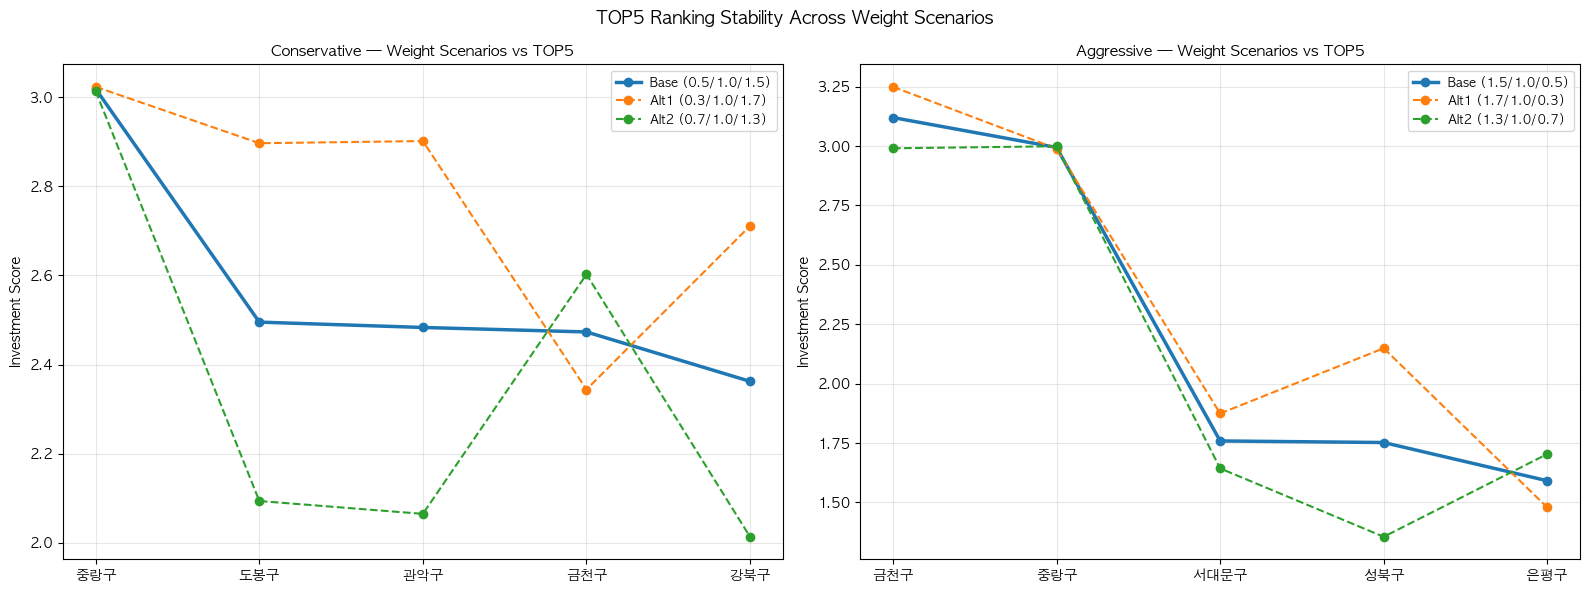

-> Similar line shapes across scenarios indicate the TOP3 ranking is robust to weight choice.


In [78]:
# Sensitivity Analysis (Weight Robustness)
# If the TOP3 recommendation only holds under one exact weight combination, it's fragile. Testing nearby weight scenarios (±0.2)
# checks whether the recommendations are a robust pattern in the data or an artifact of the specific weights chosen.
weight_scenarios = {
    "Conservative Base (0.5/1.0/1.5)": (0.5, 1.0, 1.5),
    "Conservative Alt1 (0.3/1.0/1.7)": (0.3, 1.0, 1.7),
    "Conservative Alt2 (0.7/1.0/1.3)": (0.7, 1.0, 1.3),
    "Balanced Base (1.0/1.0/1.0)": (1.0, 1.0, 1.0),
    "Aggressive Base (1.5/1.0/0.5)": (1.5, 1.0, 0.5),
    "Aggressive Alt1 (1.7/1.0/0.3)": (1.7, 1.0, 0.3),
    "Aggressive Alt2 (1.3/1.0/0.7)": (1.3, 1.0, 0.7),
}
 
print("Weight Scenario -> TOP3 District Comparison")
results = {}
for scenario_name, (wg, wp, wv) in weight_scenarios.items():
    temp = district_scores.copy()
    temp["scenario_score"] = wg * temp["growth_score"] + wp * temp["price_score"] + wv * temp["volatility_score"]
    top3 = temp.sort_values("scenario_score", ascending=False).head(3)["district"].tolist()
    results[scenario_name] = top3
    print(f"{scenario_name}\n  TOP3: {top3[0]}, {top3[1]}, {top3[2]}")
 
all_top3 = [d for top in results.values() for d in top]
freq = Counter(all_top3).most_common(10)
print("\nDistrict frequency in TOP3 across all scenarios:")
for district, cnt in freq:
    print(f"  {district:8s}: {'█' * cnt} ({cnt}/{len(weight_scenarios)} scenarios)")
 
# Visual check: if TOP5 scores move in similar patterns across weight
# variants, the ranking isn't hypersensitive to the exact weights chosen.
safe_scenarios = {
    "Base (0.5/1.0/1.5)": (0.5, 1.0, 1.5),
    "Alt1 (0.3/1.0/1.7)": (0.3, 1.0, 1.7),
    "Alt2 (0.7/1.0/1.3)": (0.7, 1.0, 1.3),
}
aggr_scenarios = {
    "Base (1.5/1.0/0.5)": (1.5, 1.0, 0.5),
    "Alt1 (1.7/1.0/0.3)": (1.7, 1.0, 0.3),
    "Alt2 (1.3/1.0/0.7)": (1.3, 1.0, 0.7),
}
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("TOP5 Ranking Stability Across Weight Scenarios", fontsize=13, fontweight="bold")
colors_line = ["#1f77b4", "#ff7f0e", "#2ca02c"]
 
for ax, scenarios, title in [
    (axes[0], safe_scenarios, "Conservative — Weight Scenarios vs TOP5"),
    (axes[1], aggr_scenarios, "Aggressive — Weight Scenarios vs TOP5"),
]:
    base_w = list(scenarios.values())[0]
    temp_base = district_scores.copy()
    temp_base["score"] = (base_w[0] * temp_base["growth_score"] + base_w[1] * temp_base["price_score"]
                           + base_w[2] * temp_base["volatility_score"])
    top5_districts = temp_base.sort_values("score", ascending=False).head(5)["district"].tolist()
 
    x = range(len(top5_districts))
    for idx, (sname, (wg, wp, wv)) in enumerate(scenarios.items()):
        temp = district_scores.copy()
        temp["score"] = wg * temp["growth_score"] + wp * temp["price_score"] + wv * temp["volatility_score"]
        scores = temp[temp["district"].isin(top5_districts)].set_index("district").loc[top5_districts]["score"]
        lw = 2.5 if idx == 0 else 1.5
        ls = "-" if idx == 0 else "--"
        ax.plot(x, scores.values, marker="o", linewidth=lw, linestyle=ls, color=colors_line[idx], label=sname)
 
    ax.set_xticks(list(x))
    ax.set_xticklabels(top5_districts, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Investment Score")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()
print("-> Similar line shapes across scenarios indicate the TOP3 ranking is robust to weight choice.")

Training window: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)] | Holdout window: [np.int64(2022), np.int64(2023), np.int64(2024)]
[Conservative] TOP3 using ONLY [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)] data: ['성북구', '중랑구', '구로구']
[Balanced] TOP3 using ONLY [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)] data: ['성북구', '중랑구', '금천구']
[Aggressive] TOP3 using ONLY [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)] data: ['성북구', '노원구', '중랑구']

Seoul average growth rate during holdout window ([np.int64(2022), np.int64(2023), np.int64(2024)]): 9.53%

VALIDATION RESULT: Did training-window TOP3 picks outperform the Seoul average?
[Conservative] TOP3: ['성북구', '중랑구', '구로구']
  Actual avg growth during [np.int64(2022), np.int64(2023), np.int64(2024)]: 7.29% vs Seoul avg 9.53%
  Did NOT outperform
[Balanced] TOP3: ['성북구', '중랑구', '금천구']
  Actual avg growth during [np.int64(2022), np.int64(2023), np.int64(2024)]: 5.61% vs Seoul 

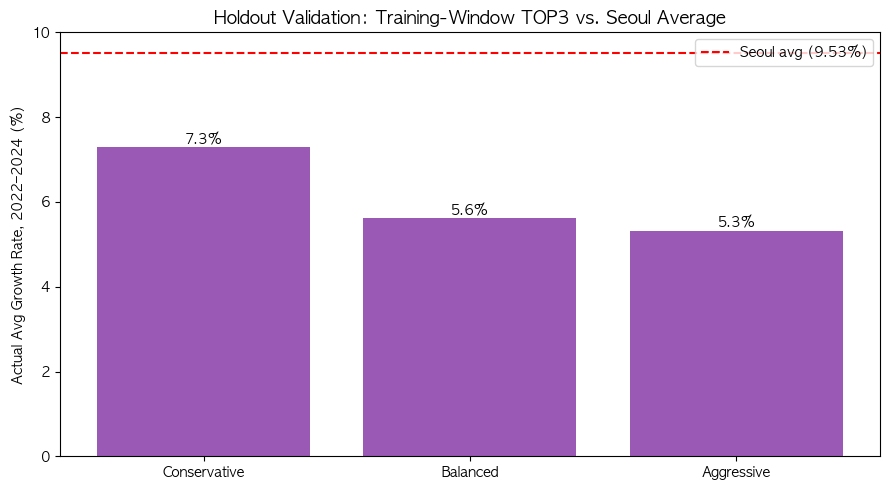

In [79]:
# Temporal Holdout Validation
# Every result so far describes the PAST. The framework's real claim is forward-looking: "districts that score well should turn out to have been good investments." 
# This tests that claim directly by computing
# TOP3 rankings using ONLY 2018-2021 data, then checking whether those
# picks actually outperformed the Seoul average during 2022-2024 — years the scoring never saw.
#
# Limitation: this is a single train/holdout split (4yr train, 3yr holdout), not a multi-fold backtest — there isn't enough history in this dataset for more folds. 
# Read the result as "does the framework show ANY forward-looking validity," not as a performance guarantee.

TRAIN_YEARS = [y for y in years if y <= 2021]
HOLDOUT_YEARS = [y for y in years if y > 2021]
print(f"Training window: {TRAIN_YEARS} | Holdout window: {HOLDOUT_YEARS}")
 
if len(TRAIN_YEARS) < 3 or len(HOLDOUT_YEARS) < 2:
    raise ValueError("Not enough years on one side of the split — check `years` covers 2018-2024.")
 
df_train = df_all[df_all["year"].isin(TRAIN_YEARS)]
df_holdout = df_all[df_all["year"].isin(HOLDOUT_YEARS)]
 
 
def compute_metrics(df_subset, year_list):
    """Same growth/volatility logic as CELL 7, scoped to an arbitrary
    year window, so the training-window metrics are computed identically
    to the full-period ones."""
    pivot = df_subset.pivot_table(index="district", columns="year", values="price_per_pyeong", aggfunc="mean")
    metrics = pivot.copy()
    for i in range(1, len(year_list)):
        pre_y, cur_y = year_list[i - 1], year_list[i]
        if pre_y in metrics.columns and cur_y in metrics.columns:
            metrics[f"growth_{pre_y}_{cur_y}"] = (metrics[cur_y] - metrics[pre_y]) / metrics[pre_y] * 100
    growth_cols = [c for c in metrics.columns if str(c).startswith("growth_")]
    metrics["avg_growth_rate"] = metrics[growth_cols].mean(axis=1)
    metrics["growth_volatility"] = metrics[growth_cols].std(axis=1)
    metrics["current_price_per_pyeong"] = metrics[year_list[-1]]
    return metrics.reset_index()
 
 
train_metrics = compute_metrics(df_train, TRAIN_YEARS)
for col in ["avg_growth_rate", "current_price_per_pyeong", "growth_volatility"]:
    m, s = train_metrics[col].mean(), train_metrics[col].std()
    train_metrics[f"{col}_z"] = (train_metrics[col] - m) / s
 
train_metrics["growth_score"] = train_metrics["avg_growth_rate_z"]
train_metrics["price_score"] = -train_metrics["current_price_per_pyeong_z"]
train_metrics["volatility_score"] = -train_metrics["growth_volatility_z"]
 
PROFILE_WEIGHTS = {"conservative": (0.5, 1.0, 1.5), "balanced": (1.0, 1.0, 1.0), "aggressive": (1.5, 1.0, 0.5)}
 
train_rankings = {}
for profile, (wg, wp, wv) in PROFILE_WEIGHTS.items():
    train_metrics[f"{profile}_score"] = wg * train_metrics["growth_score"] + wp * train_metrics["price_score"] + wv * train_metrics["volatility_score"]
    train_rankings[profile] = train_metrics.sort_values(f"{profile}_score", ascending=False).head(3)["district"].tolist()
    print(f"[{profile.capitalize()}] TOP3 using ONLY {TRAIN_YEARS} data: {train_rankings[profile]}")
 
holdout_metrics = compute_metrics(df_holdout, HOLDOUT_YEARS)
seoul_holdout_avg_growth = holdout_metrics["avg_growth_rate"].mean()
print(f"\nSeoul average growth rate during holdout window ({HOLDOUT_YEARS}): {seoul_holdout_avg_growth:.2f}%")
 
print("\nVALIDATION RESULT: Did training-window TOP3 picks outperform the Seoul average?")
validation_rows = []
for profile, districts in train_rankings.items():
    actual = holdout_metrics[holdout_metrics["district"].isin(districts)]
    actual_avg_growth = actual["avg_growth_rate"].mean()
    beat_seoul = actual_avg_growth > seoul_holdout_avg_growth
    validation_rows.append({
        "profile": profile, "top3_from_training": districts,
        "actual_holdout_growth_pct": round(actual_avg_growth, 2),
        "seoul_avg_holdout_growth_pct": round(seoul_holdout_avg_growth, 2),
        "outperformed_seoul_avg": beat_seoul,
    })
    print(f"[{profile.capitalize()}] TOP3: {districts}")
    print(f"  Actual avg growth during {HOLDOUT_YEARS}: {actual_avg_growth:.2f}% vs Seoul avg {seoul_holdout_avg_growth:.2f}%")
    print(f"  {'Outperformed' if beat_seoul else 'Did NOT outperform'}")
 
validation_df = pd.DataFrame(validation_rows)
 
plt.figure(figsize=(9, 5))
bar_colors = ["#F4D13B" if row["outperformed_seoul_avg"] else "#9b59b6" for row in validation_rows]
plt.bar(validation_df["profile"].str.capitalize(), validation_df["actual_holdout_growth_pct"], color=bar_colors)
plt.axhline(seoul_holdout_avg_growth, color="red", linestyle="--", label=f"Seoul avg ({seoul_holdout_avg_growth:.2f}%)")
plt.ylabel(f"Actual Avg Growth Rate, {HOLDOUT_YEARS[0]}–{HOLDOUT_YEARS[-1]} (%)")
plt.title("Holdout Validation: Training-Window TOP3 vs. Seoul Average", fontsize=13, fontweight="bold")
plt.legend()
for i, row in enumerate(validation_rows):
    plt.text(i, row["actual_holdout_growth_pct"], f"{row['actual_holdout_growth_pct']:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

Conservative building-type ranking (TOP5):
district building_type  conservative_bldg_score
     중랑구         연립다세대                 2.067395
     관악구         단독다가구                 1.520590
     도봉구         연립다세대                 1.119836
     관악구         연립다세대                 0.575323
     중랑구         단독다가구                -1.584489

Balanced building-type ranking (TOP5):
district building_type  balanced_bldg_score
     중랑구         연립다세대             2.516639
     은평구         연립다세대             1.241317
     금천구         연립다세대             1.156098
     금천구          오피스텔             0.867120
     은평구           아파트             0.723575

Aggressive building-type ranking (TOP5):
district building_type  aggressive_bldg_score
     중랑구          오피스텔               3.429400
     금천구          오피스텔               3.170100
     중랑구         연립다세대               2.965883
     금천구           아파트               2.188500
     중랑구           아파트               1.469069


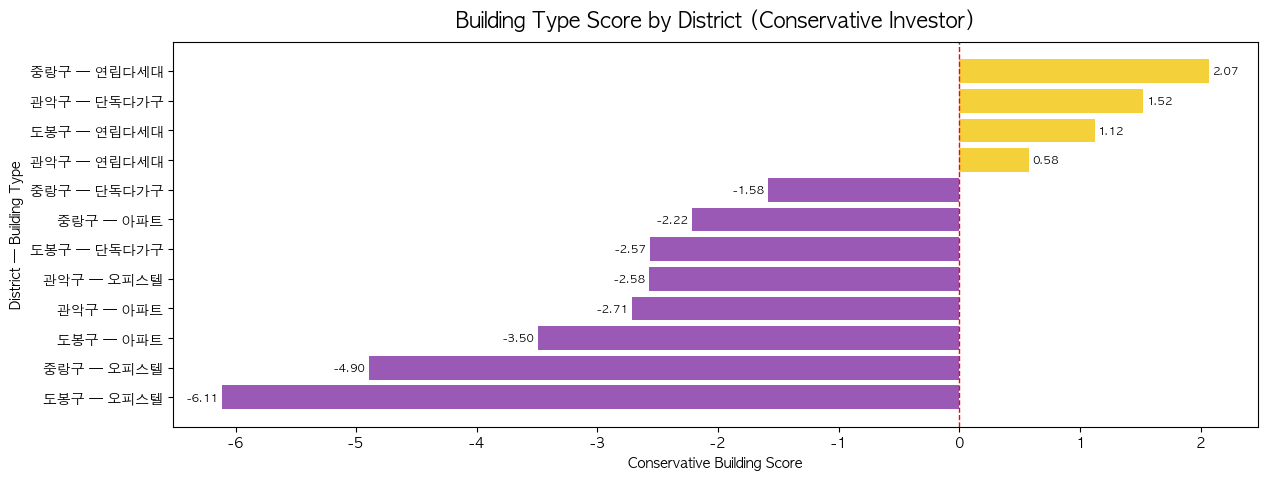

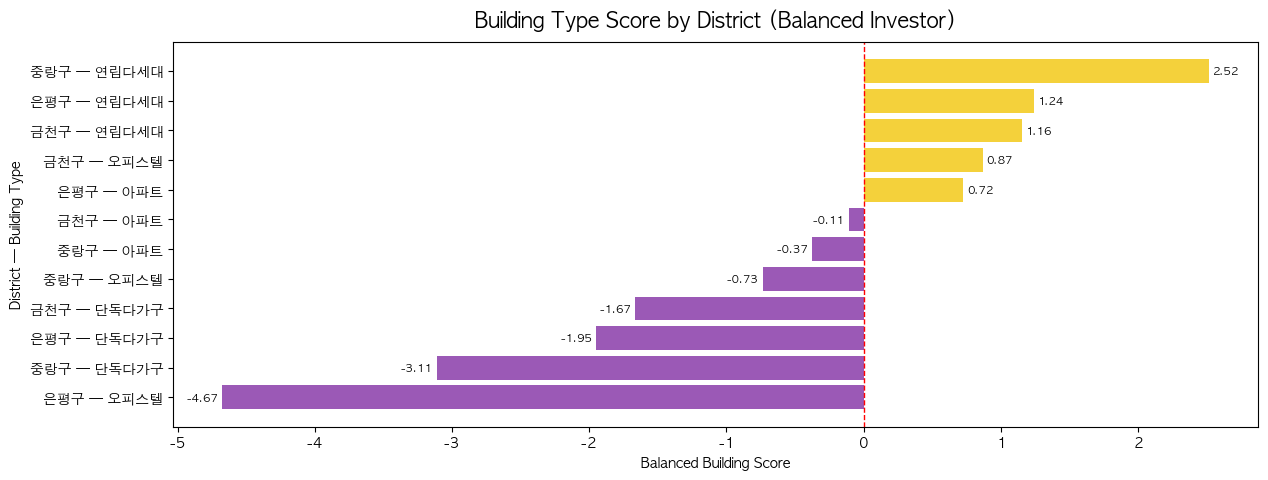

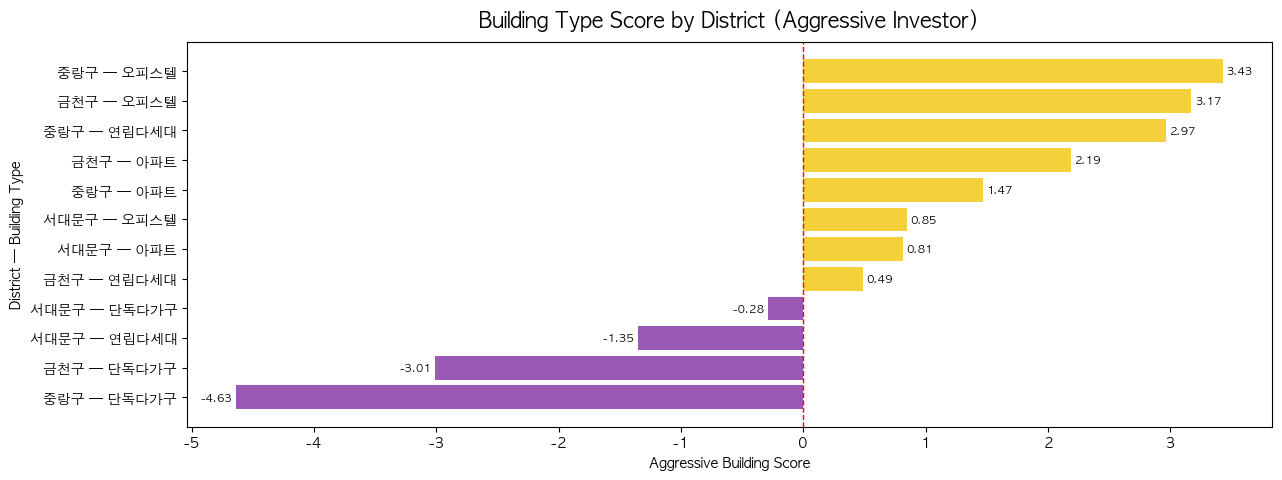

In [80]:
# Building-Type Drill-Down
# District-level TOP3 answers "which gu?" — this section re-scores building types WITHIN each profile's TOP3 districts to answer
# "which building type in that gu?" 
# Z-scores here reuse the SAME global mean/std computed in CELL 10 (not recomputed within the TOP3
# subset), so district-level and building-type-level scores stay on one consistent scale and the final ranking doesn't silently diverge from the district-level TOP3 order.
def bldg_type_scores(rank_df, weights, label):
    top3_list = rank_df.head(3)["district"].tolist()
    df_top = df_all[df_all["district"].isin(top3_list)].copy()
    pivot = df_top.pivot_table(index=["district", "building_type"], columns="year",
                                values="price_per_pyeong", aggfunc="mean").reset_index()
    for i in range(1, len(years)):
        pre_y, cur_y = years[i - 1], years[i]
        pivot[f"growth_{pre_y}_{cur_y}"] = (pivot[cur_y] - pivot[pre_y]) / pivot[pre_y] * 100
    g_cols = [c for c in pivot.columns if str(c).startswith("growth_")]
    pivot["avg_growth_rate"] = pivot[g_cols].mean(axis=1)
    pivot["growth_volatility"] = pivot[g_cols].std(axis=1)
    pivot["current_price_per_pyeong"] = pivot[years[-1]]
 
    pivot["growth_z"] = (pivot["avg_growth_rate"] - mean_growth) / std_growth
    pivot["price_z"] = -(pivot["current_price_per_pyeong"] - mean_price) / std_price
    pivot["volatility_z"] = -(pivot["growth_volatility"] - mean_vol) / std_vol
 
    wg, wp, wv = weights
    pivot[f"{label}_bldg_score"] = wg * pivot["growth_z"] + wp * pivot["price_z"] + wv * pivot["volatility_z"]
    return pivot.sort_values(f"{label}_bldg_score", ascending=False).reset_index(drop=True)
 
 
cons_bldg_rank = bldg_type_scores(conservative_rank, (0.5, 1.0, 1.5), "conservative")
bal_bldg_rank = bldg_type_scores(balanced_rank, (1.0, 1.0, 1.0), "balanced")
aggr_bldg_rank = bldg_type_scores(aggressive_rank, (1.5, 1.0, 0.5), "aggressive")
 
print("Conservative building-type ranking (TOP5):")
print(cons_bldg_rank[["district", "building_type", "conservative_bldg_score"]].head().to_string(index=False))
print("\nBalanced building-type ranking (TOP5):")
print(bal_bldg_rank[["district", "building_type", "balanced_bldg_score"]].head().to_string(index=False))
print("\nAggressive building-type ranking (TOP5):")
print(aggr_bldg_rank[["district", "building_type", "aggressive_bldg_score"]].head().to_string(index=False))
 
for bldg_rank, score_col, title in [
    (cons_bldg_rank, "conservative_bldg_score", "Conservative"),
    (bal_bldg_rank, "balanced_bldg_score", "Balanced"),
    (aggr_bldg_rank, "aggressive_bldg_score", "Aggressive"),
]:
    df_r = bldg_rank.copy()
    df_r["label"] = df_r["district"] + " — " + df_r["building_type"]
    df_r = df_r.sort_values(score_col, ascending=True).reset_index(drop=True)
    colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in df_r[score_col]]
    plt.figure(figsize=(14, 5))
    plt.barh(df_r["label"], df_r[score_col], color=colors)
    plt.title(f"Building Type Score by District ({title} Investor)", fontsize=15, fontweight="bold", pad=10)
    plt.xlabel(f"{title} Building Score")
    plt.ylabel("District — Building Type")
    for i, v in enumerate(df_r[score_col]):
        x_pos = v + 0.03 if v >= 0 else v - 0.03
        ha = "left" if v >= 0 else "right"
        plt.text(x_pos, i, f"{v:.2f}", va="center", ha=ha, fontsize=8)
    plt.axvline(0, color="red", linestyle="--", linewidth=1)
    plt.show()


CONSERVATIVE — TOP 5 Dongs within TOP3 Districts ['중랑구', '도봉구', '관악구']
district dong  conservative_dong_score  avg_growth_rate  growth_volatility  current_price_per_pyeong  n_transactions  low_confidence
     중랑구  면목동                    3.624           11.772              4.652                  3083.568            9461           False
     중랑구  중화동                    3.533           10.592              4.587                  2860.772            3532           False
     도봉구  방학동                    3.467            5.364              3.785                  1837.561            7177           False
     중랑구  망우동                    2.317            8.616              6.523                  2388.452            2955           False
     도봉구   창동                    1.600            6.913              6.448                  2590.767           11530           False

BALANCED — TOP 5 Dongs within TOP3 Districts ['중랑구', '금천구', '은평구']
district dong  balanced_dong_score  avg_growth_rate  growth_vo

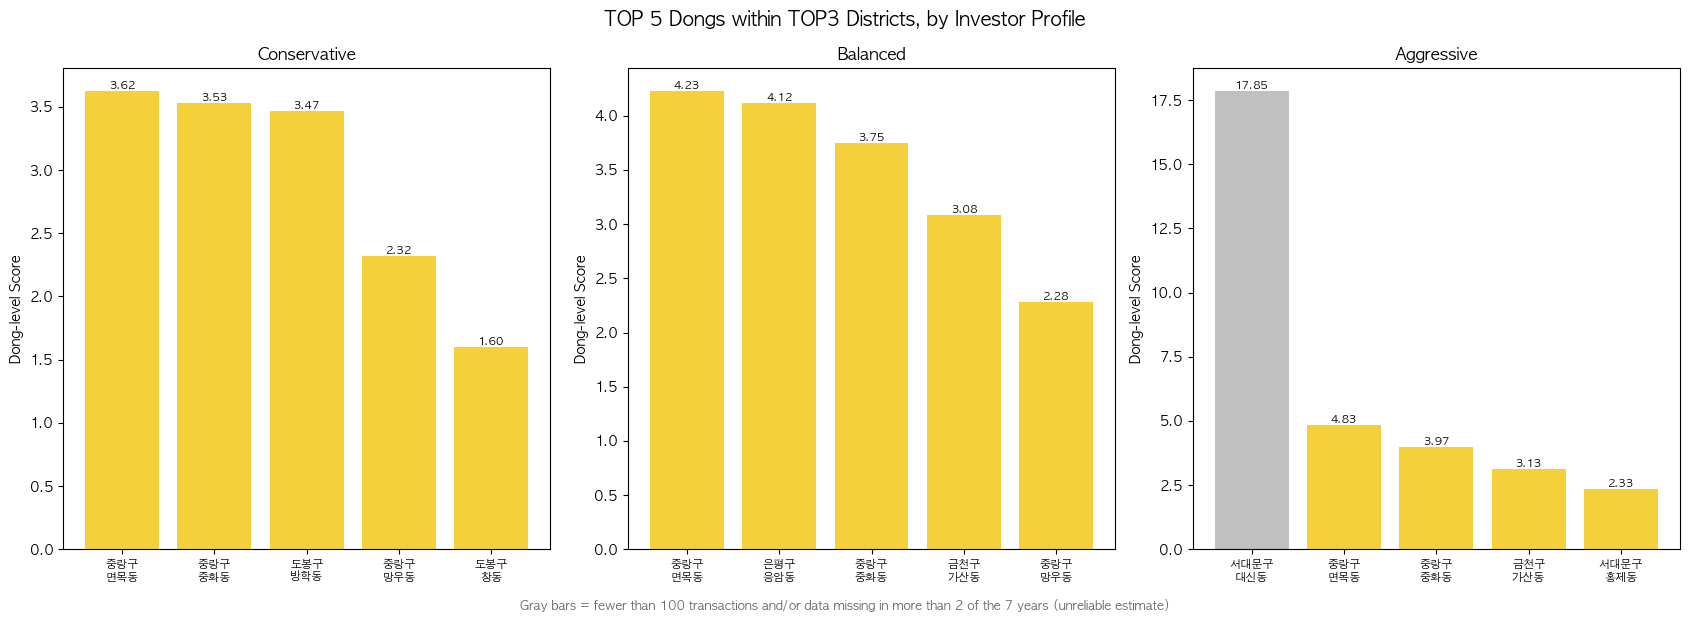

In [81]:
# Dong-Level Drill-Down
# One more level of resolution: within each profile's TOP3 districts, which specific dong (neighborhood) stands out? A gu-level average can
# mask very different sub-markets (e.g. one dong doing well while another in the same gu lags).
#
# Dong-level transaction counts are far smaller than district-level ones, so growth/volatility estimates get noisier. 
# low_confidence flags dongs with either fewer than 100 transactions OR data missing in more than 2 of the 7 years — either condition alone is enough to
# make a YoY growth estimate unreliable. This threshold was set after an earlier pass with a 30-transaction floor let a single thinly
# traded dong through with a growth rate an order of magnitude out of line with every other result.
if "dong" not in df_all.columns:
    raise KeyError("'dong' column not found — check 법정동명 survived the rename in CELL 4.")
 
GLOBAL_STATS = dict(mean_growth=mean_growth, std_growth=std_growth,
                     mean_price=mean_price, std_price=std_price,
                     mean_vol=mean_vol, std_vol=std_vol)
 
 
def compute_dong_metrics(df_subset, years, global_stats, min_transactions=100, min_year_coverage=None):
    if min_year_coverage is None:
        min_year_coverage = len(years) - 2
 
    dong_counts = df_subset.groupby("dong").size().rename("n_transactions")
    pivot = df_subset.pivot_table(index="dong", columns="year", values="price_per_pyeong", aggfunc="mean")
    year_coverage = pivot[years].notna().sum(axis=1).rename("year_coverage")
 
    metrics = pivot.copy()
    for i in range(1, len(years)):
        pre_y, cur_y = years[i - 1], years[i]
        if pre_y in metrics.columns and cur_y in metrics.columns:
            metrics[f"growth_{pre_y}_{cur_y}"] = (metrics[cur_y] - metrics[pre_y]) / metrics[pre_y] * 100
 
    growth_cols = [c for c in metrics.columns if str(c).startswith("growth_")]
    metrics["avg_growth_rate"] = metrics[growth_cols].mean(axis=1)
    metrics["growth_volatility"] = metrics[growth_cols].std(axis=1)
    metrics["current_price_per_pyeong"] = metrics[years[-1]]
    metrics = metrics.join(dong_counts).join(year_coverage)
    metrics["low_confidence"] = (metrics["n_transactions"] < min_transactions) | (metrics["year_coverage"] < min_year_coverage)
 
    # Z-scored against the SAME global stats used for district-level
    # scoring (CELL 10) — not recomputed within this subset — so
    # district-level and dong-level scores stay comparable.
    metrics["growth_score"] = (metrics["avg_growth_rate"] - global_stats["mean_growth"]) / global_stats["std_growth"]
    metrics["price_score"] = -(metrics["current_price_per_pyeong"] - global_stats["mean_price"]) / global_stats["std_price"]
    metrics["volatility_score"] = -(metrics["growth_volatility"] - global_stats["mean_vol"]) / global_stats["std_vol"]
    return metrics.reset_index()
 
 
def score_by_profile(metrics_df, weights):
    wg, wp, wv = weights
    return wg * metrics_df["growth_score"] + wp * metrics_df["price_score"] + wv * metrics_df["volatility_score"]
 
 
PROFILE_RANK_DF = {"conservative": conservative_rank, "balanced": balanced_rank, "aggressive": aggressive_rank}
dong_results = {}
 
for profile, rank_df in PROFILE_RANK_DF.items():
    top3_districts = rank_df.head(3)["district"].tolist()
    df_scope = df_all[df_all["district"].isin(top3_districts)].copy()
    dong_metrics = compute_dong_metrics(df_scope, years, GLOBAL_STATS)
 
    dong_to_district = df_scope[["dong", "district"]].drop_duplicates().set_index("dong")["district"]
    dong_metrics["district"] = dong_metrics["dong"].map(dong_to_district)
    dong_metrics[f"{profile}_dong_score"] = score_by_profile(dong_metrics, PROFILE_WEIGHTS[profile])
    dong_metrics = dong_metrics.sort_values(f"{profile}_dong_score", ascending=False).reset_index(drop=True)
    dong_results[profile] = dong_metrics
 
    print(f"\n{profile.upper()} — TOP 5 Dongs within TOP3 Districts {top3_districts}")
    cols = ["district", "dong", f"{profile}_dong_score", "avg_growth_rate",
            "growth_volatility", "current_price_per_pyeong", "n_transactions", "low_confidence"]
    print(dong_metrics[cols].head(5).round(3).to_string(index=False))
 
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle("TOP 5 Dongs within TOP3 Districts, by Investor Profile", fontsize=14, fontweight="bold")
for ax, (profile, df_r) in zip(axes, dong_results.items()):
    top5 = df_r.head(5)
    score_col = f"{profile}_dong_score"
    labels = top5["district"] + "\n" + top5["dong"]
    bar_colors = ["#F4D13B" if not lc else "#C0C0C0" for lc in top5["low_confidence"]]
    ax.bar(range(len(top5)), top5[score_col], color=bar_colors)
    ax.set_xticks(range(len(top5)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(profile.capitalize(), fontsize=12)
    ax.set_ylabel("Dong-level Score")
    for i, v in enumerate(top5[score_col]):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
fig.text(0.5, -0.02, "Gray bars = fewer than 100 transactions and/or data missing in "
         "more than 2 of the 7 years (unreliable estimate)", ha="center", fontsize=9, color="dimgray")
plt.tight_layout()
plt.show()
 

In [82]:
# Final Recommendations Summary
def get_top3_labels(rank_df, score_col):
    top = rank_df.head(3)
    return [f"{r['district']} ({r['building_type']})" for _, r in top.iterrows()]
 
 
summary_df = pd.DataFrame({
    "Investor Profile": ["Conservative", "Balanced", "Aggressive"],
    "Weights (Growth/Price/Vol)": ["0.5 / 1.0 / 1.5", "1.0 / 1.0 / 1.0", "1.5 / 1.0 / 0.5"],
    "TOP 1": [get_top3_labels(cons_bldg_rank, "conservative_bldg_score")[0],
              get_top3_labels(bal_bldg_rank, "balanced_bldg_score")[0],
              get_top3_labels(aggr_bldg_rank, "aggressive_bldg_score")[0]],
    "TOP 2": [get_top3_labels(cons_bldg_rank, "conservative_bldg_score")[1],
              get_top3_labels(bal_bldg_rank, "balanced_bldg_score")[1],
              get_top3_labels(aggr_bldg_rank, "aggressive_bldg_score")[1]],
    "TOP 3": [get_top3_labels(cons_bldg_rank, "conservative_bldg_score")[2],
              get_top3_labels(bal_bldg_rank, "balanced_bldg_score")[2],
              get_top3_labels(aggr_bldg_rank, "aggressive_bldg_score")[2]],
})
 
print("Final Recommended Districts & Building Types by Investor Profile")
print(summary_df.to_string(index=False))
 
print(
    "\n[Reading this table alongside the rest of the notebook]\n"
    "- Dong-level results (CELL 17) should be read net of any row flagged\n"
    "  low_confidence=True — e.g. a thinly traded dong can post an outlier\n"
    "  score from noisy YoY growth on a small transaction count, not a real\n"
    "  signal.\n"
    "- The temporal holdout validation (CELL 15) showed all three profiles'\n"
    "  training-window TOP3 underperforming the Seoul average during\n"
    "  2022-2024. That period's gains concentrated in already-premium\n"
    "  districts (a re-rating pattern) rather than the undervalued/stable\n"
    "  districts this framework favors — a legitimate limitation of a\n"
    "  static, backward-looking scoring system, not a data error.\n"
    "- The regression (CELL 13) and the Z-score ranking above can rank the\n"
    "  same district differently because they answer different questions:\n"
    "  Z-score asks whether the district's CURRENT average price is low;\n"
    "  the regression asks whether the district itself is cheap once\n"
    "  building type/floor/age/year are held constant. A district can rank\n"
    "  well on one and not the other if its low raw average is driven by\n"
    "  its housing-stock mix rather than the location itself."
)

Final Recommended Districts & Building Types by Investor Profile
Investor Profile Weights (Growth/Price/Vol)       TOP 1       TOP 2       TOP 3
    Conservative            0.5 / 1.0 / 1.5 중랑구 (연립다세대) 관악구 (단독다가구) 도봉구 (연립다세대)
        Balanced            1.0 / 1.0 / 1.0 중랑구 (연립다세대) 은평구 (연립다세대) 금천구 (연립다세대)
      Aggressive            1.5 / 1.0 / 0.5  중랑구 (오피스텔)  금천구 (오피스텔) 중랑구 (연립다세대)

[Reading this table alongside the rest of the notebook]
- Dong-level results (CELL 17) should be read net of any row flagged
  low_confidence=True — e.g. a thinly traded dong can post an outlier
  score from noisy YoY growth on a small transaction count, not a real
  signal.
- The temporal holdout validation (CELL 15) showed all three profiles'
  training-window TOP3 underperforming the Seoul average during
  2022-2024. That period's gains concentrated in already-premium
  districts (a re-rating pattern) rather than the undervalued/stable
  districts this framework favors — a legitimate limitation of a
  st